## Predicción de Churn en Automoción

**Pipeline:** `DATOS → VALIDAR → EDA → FE (Baseline B) → TRAIN → ITERAR → TEST → WINNER`

---

In [207]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, f1_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pickle

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42

print('Librerías cargadas correctamente')


Librerías cargadas correctamente


---
## 1. DATOS — Carga del dataset de entrenamiento

In [208]:
df = pd.read_csv('datos_churn_entrenamiento.csv', low_memory=False)
df_new = pd.read_csv('nuevos_clientes.csv', low_memory=False)

print(f'Train: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Nuevos clientes: {df_new.shape[0]:,} filas × {df_new.shape[1]} columnas')
df.head(3)

Train: 58,049 filas × 40 columnas
Nuevos clientes: 10,000 filas × 38 columnas


,CODE,Sales_Date,Id_Producto,Customer_ID,PVP,MOTIVO_VENTA,FORMA_PAGO,EXTENSION_GARANTIA,SEGURO_BATERIA_LARGO_PLAZO,MANTENIMIENTO_GRATUITO,...,Lead_compra,Fue_Lead,TIENDA_DESC,PROV_DESC,ZONA,Origen,Margen_eur_bruto,Margen_eur,DAYS_LAST_SERVICE,Churn_400
0,ID22371,14/03/2022,PA100006,70426,10528,Particular,Financiera Marca,NO,NO,0,...,0,0,BILBAO,BILBAO,NORTE,Tienda,2328.79,1247.08,117.0,N
1,ID22373,20/06/2023,PA100006,53124,10528,Particular,Contado,NO,NO,0,...,0,1,BARCELONA NORTE,BARCELONA,ESTE,Internet,2328.79,1247.08,NaN,N
2,ID22380,21/03/2021,PA100006,39623,10528,Particular,Contado,NO,NO,0,...,0,0,MADRID SUR,MADRID,CENTRO,Tienda,2328.79,1247.08,NaN,N


---
## 2. VALIDAR — Calidad y coherencia del dataset

In [209]:
# --- Tipos de datos y nulos ---
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(1),
    'únicos': df.nunique()
})
print(info.sort_values('nulos_%', ascending=False).to_string())

                                dtype  nulos  nulos_%  únicos
QUEJA                          object  33323     57.4       2
DAYS_LAST_SERVICE             float64  27070     46.6    1467
STATUS_SOCIAL                  object  12816     22.1      12
GENERO                         object    849      1.5       2
CODE                           object      0      0.0   58049
TRANSMISION_ID                 object      0      0.0       2
Equipamiento                   object      0      0.0       4
Kw                              int64      0      0.0      39
Revisiones                      int64      0      0.0       9
Km_medio_por_revision           int64      0      0.0   21561
km_ultima_revision              int64      0      0.0   25988
Lead_compra                     int64      0      0.0       2
TIPO_CARROCERIA                object      0      0.0       8
Fue_Lead                        int64      0      0.0       2
TIENDA_DESC                    object      0      0.0      12
PROV_DES

Target — Churn_400:
           count     %
Churn_400             
N          52956  91.2
Y           5093   8.8


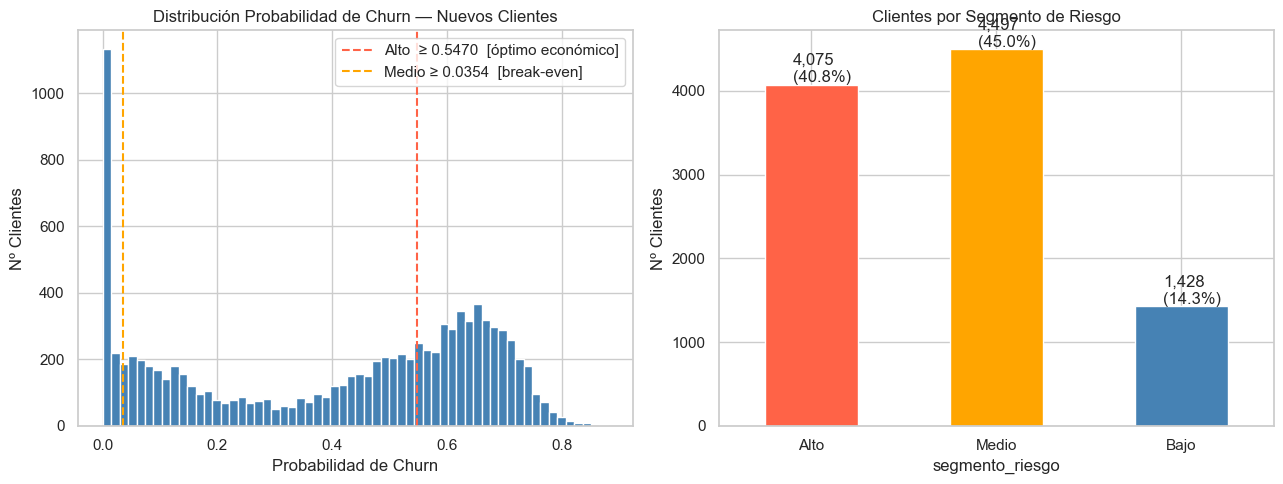

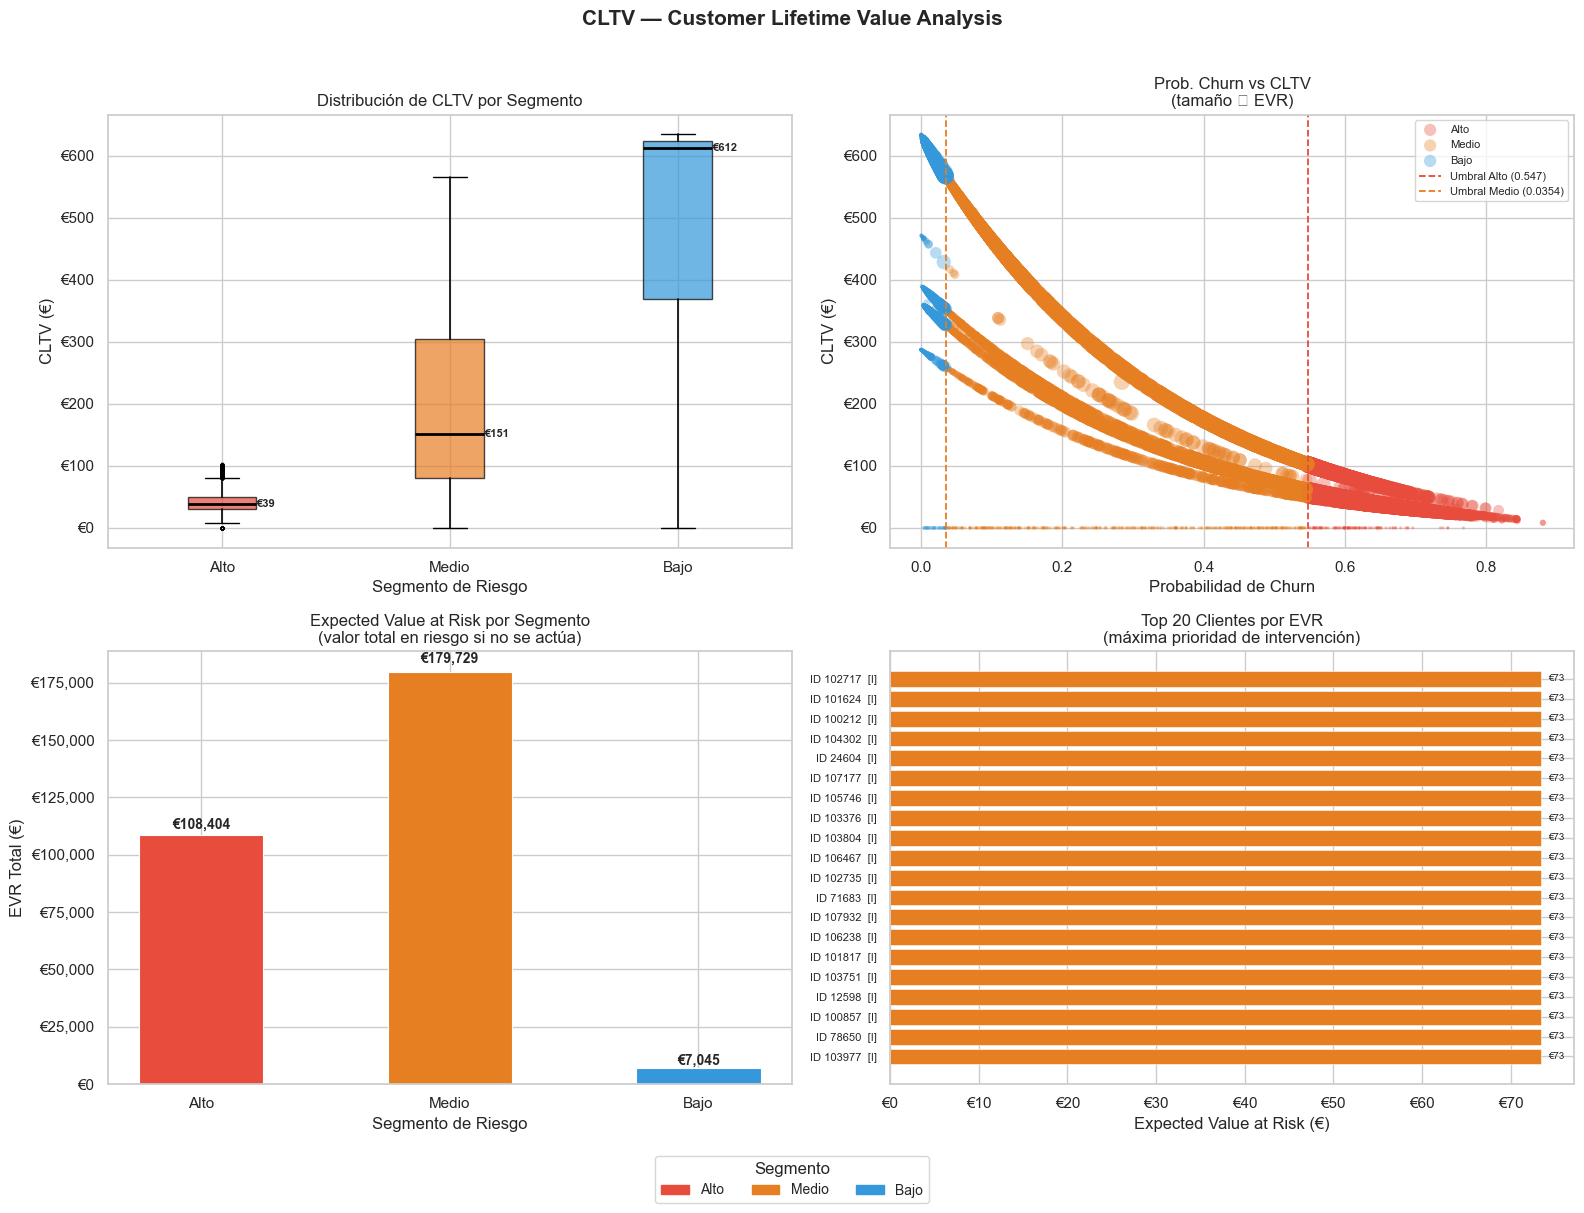

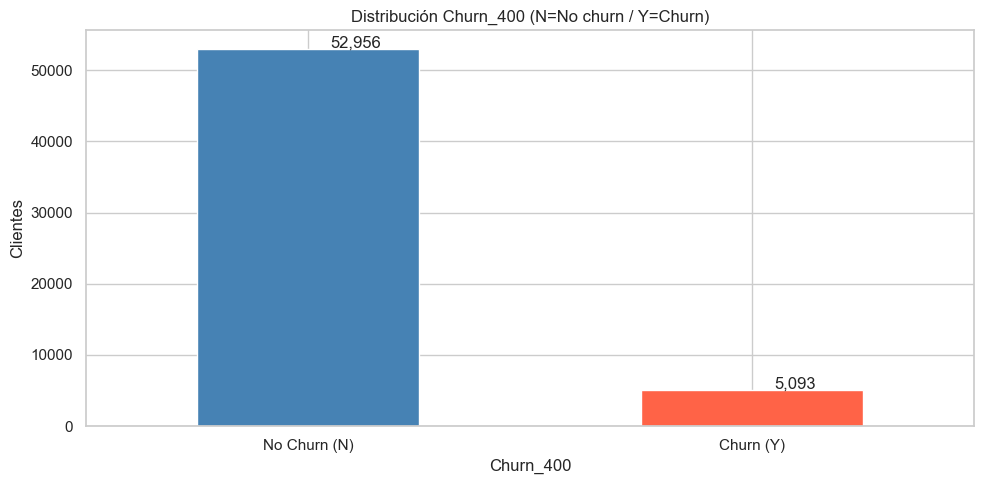

In [210]:
# --- Distribución del target ---
target_dist = df['Churn_400'].value_counts()
target_pct  = df['Churn_400'].value_counts(normalize=True) * 100
print('Target — Churn_400:')
print(pd.DataFrame({'count': target_dist, '%': target_pct.round(1)}))

fig, ax = plt.subplots()
target_dist.plot(kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='white')
ax.set_title('Distribución Churn_400 (N=No churn / Y=Churn)')
ax.set_ylabel('Clientes')
ax.set_xticklabels(['No Churn (N)', 'Churn (Y)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x()+0.3, p.get_height()+200))
plt.tight_layout()
plt.show()

In [211]:
# --- Validar variables clave ---
print('Modelos únicos:', df['Modelo'].unique())
print('Fuel tipos:', df['Fuel'].unique())
print('Churn valores:', df['Churn_400'].unique())
print('Revisiones — min/max:', df['Revisiones'].min(), '/', df['Revisiones'].max())
print('PVP — min/max:', df['PVP'].min(), '/', df['PVP'].max())
print('Edad — min/max:', df['Edad'].min(), '/', df['Edad'].max())

Modelos únicos: ['A' 'B' 'H' 'D' 'E' 'C' 'I' 'G' 'J' 'K' 'F']
Fuel tipos: ['HÍBRIDO' 'ELÉCTRICO']
Churn valores: ['N' 'Y']
Revisiones — min/max: 0 / 8
PVP — min/max: 10528 / 37970
Edad — min/max: 20 / 78


In [212]:
# --- Columnas en train pero NO en nuevos_clientes (no se pueden usar como features) ---
solo_train = set(df.columns) - set(df_new.columns)
print('Columnas solo en train (excluir de features):', solo_train)

Columnas solo en train (excluir de features): {'Fue_Lead', 'Churn_400', 'DAYS_LAST_SERVICE'}


---
## 3. EDA — Análisis Exploratorio

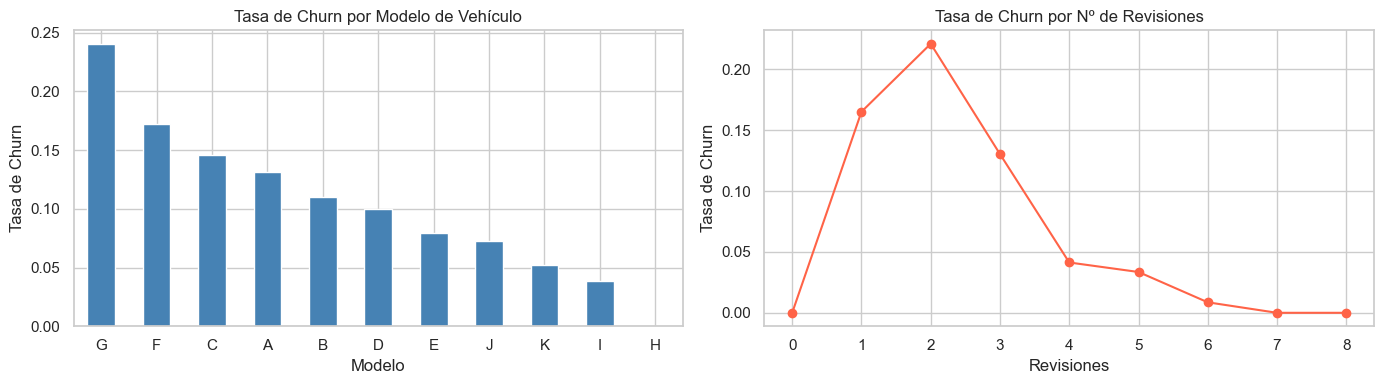

In [213]:
# Binarizar target para análisis
df['target'] = (df['Churn_400'] == 'Y').astype(int)

# --- Tasa de churn por Modelo ---
churn_modelo = df.groupby('Modelo')['target'].mean().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

churn_modelo.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Tasa de Churn por Modelo de Vehículo')
axes[0].set_ylabel('Tasa de Churn')
axes[0].set_xticklabels(churn_modelo.index, rotation=0)

# --- Tasa de churn por número de revisiones ---
churn_rev = df.groupby('Revisiones')['target'].mean()
churn_rev.plot(ax=axes[1], marker='o', color='tomato')
axes[1].set_title('Tasa de Churn por Nº de Revisiones')
axes[1].set_ylabel('Tasa de Churn')
axes[1].set_xlabel('Revisiones')

plt.tight_layout()
plt.show()

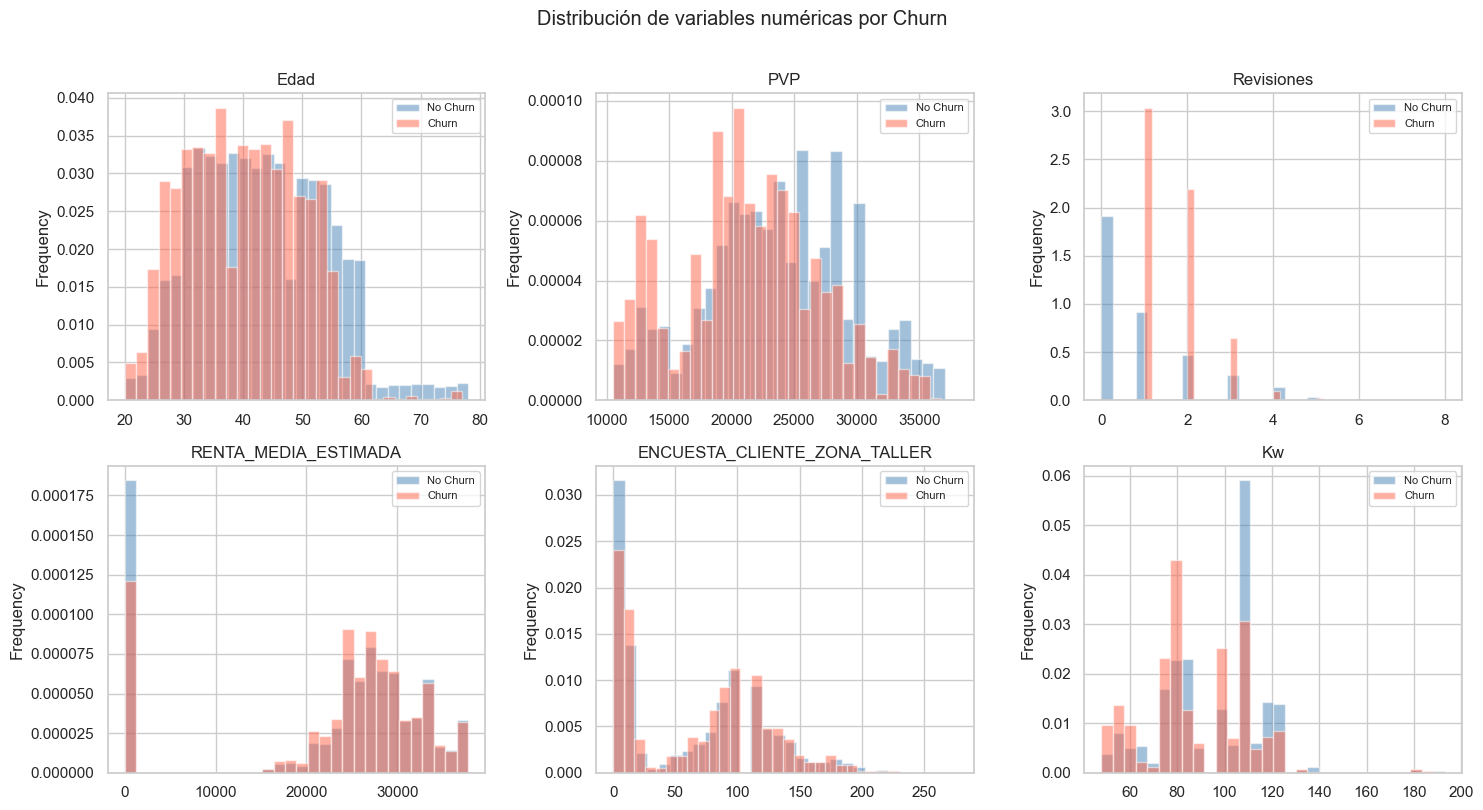

In [214]:
# --- Distribuciones numéricas por target ---
num_vars = ['Edad', 'PVP', 'Revisiones', 'RENTA_MEDIA_ESTIMADA', 'ENCUESTA_CLIENTE_ZONA_TALLER', 'Kw']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_vars):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df[df['target'] == label][col].dropna()
        subset.plot(kind='hist', bins=30, ax=ax, alpha=0.5, color=color,
                    label='No Churn' if label == 0 else 'Churn', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Distribución de variables numéricas por Churn', y=1.01)
plt.tight_layout()
plt.show()

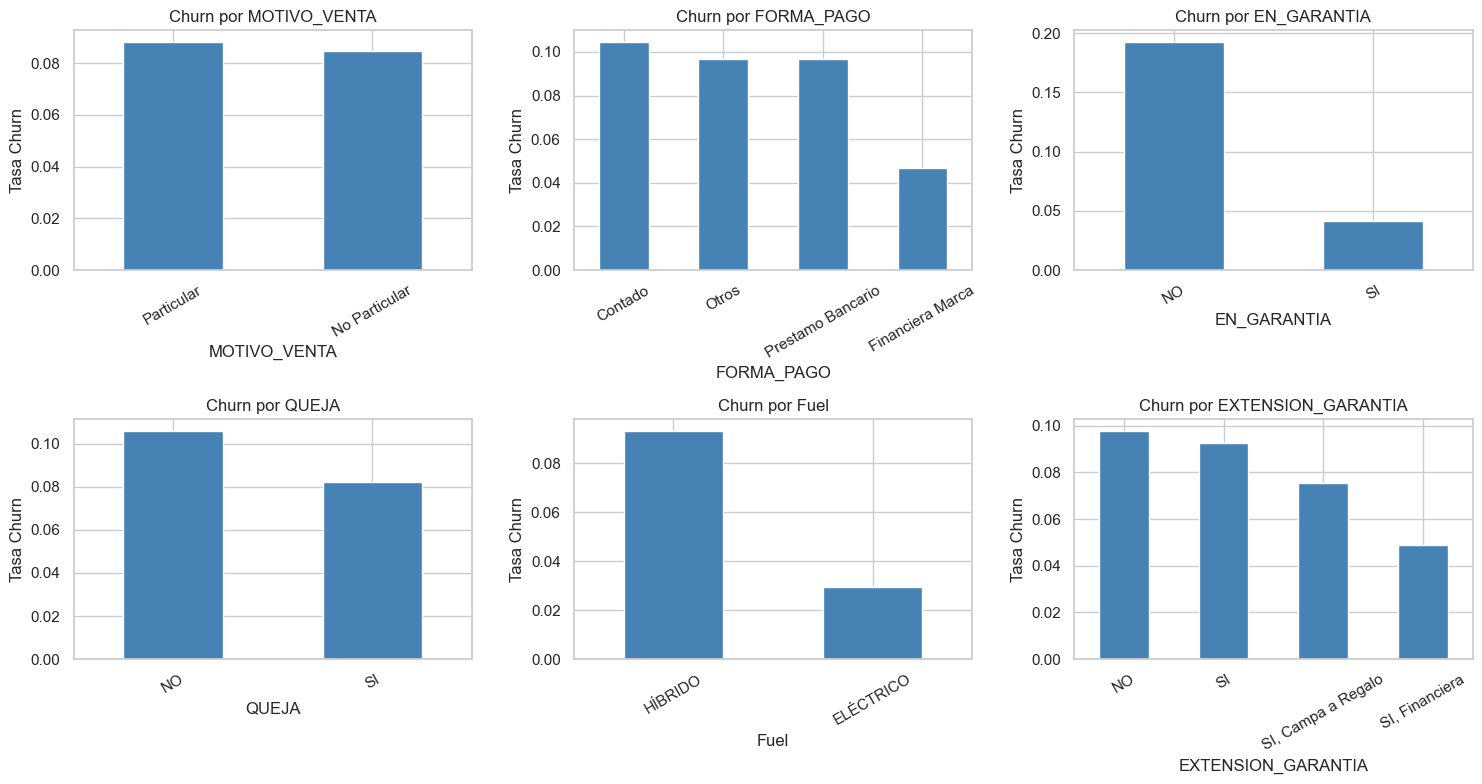

In [215]:
# --- Tasa de churn por variables categóricas ---
cat_vars = ['MOTIVO_VENTA', 'FORMA_PAGO', 'EN_GARANTIA', 'QUEJA', 'Fuel', 'EXTENSION_GARANTIA']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, cat_vars):
    rates = df.groupby(col)['target'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Churn por {col}')
    ax.set_ylabel('Tasa Churn')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

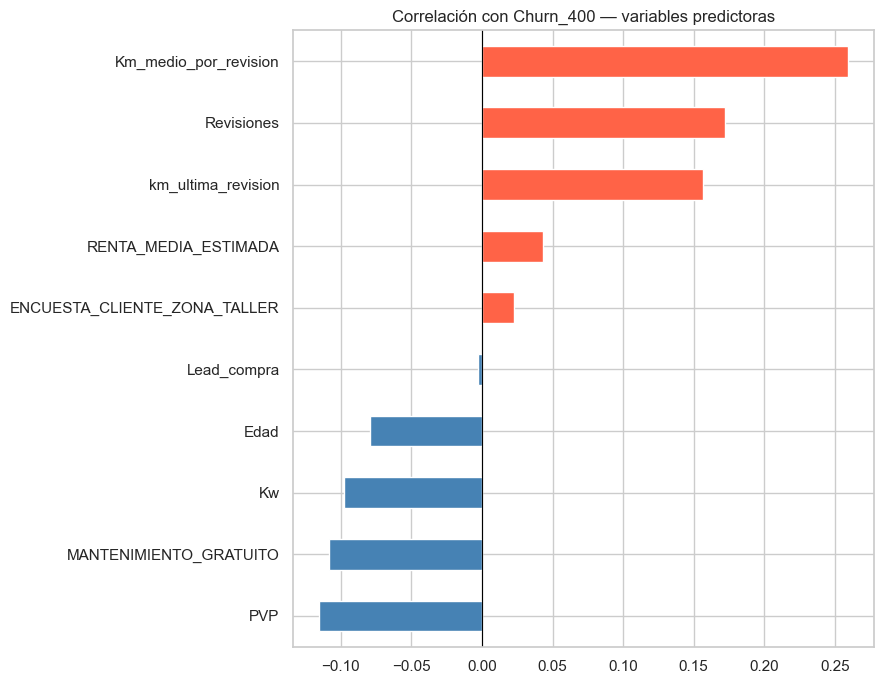

In [216]:
# --- Correlaciones numéricas (solo variables predictoras, sin leakage) ---
# Excluimos: leakage directo, financieras post-venta, y variables ya excluidas del modelo
EXCLUIR_CORR = [
    'target',
    'DAYS_LAST_SERVICE',          # leakage directo (define el target)
    'Margen_eur', 'Margen_eur_bruto', 'COSTE_VENTA_NO_IMPUESTOS',  # financieras post-venta
    'Customer_ID',                # identificador, ya excluido del modelo
    'Fue_Lead',                   # solo en train, no disponible en scoring
]

num_cols = [c for c in df.select_dtypes(include='number').columns
            if c not in EXCLUIR_CORR]

corr = df[num_cols + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
corr.plot(kind='barh', ax=ax,
          color=['tomato' if v > 0 else 'steelblue' for v in corr])
ax.set_title('Correlación con Churn_400 — variables predictoras')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 4. FEATURE ENGINEERING + BASELINE (B)

### 4.1 Ingeniería de variables

In [217]:
SNAPSHOT_DATE = pd.Timestamp('2023-12-31')   # referencia de entrenamiento
SCORING_DATE  = pd.Timestamp('2024-12-31')   # referencia para scoring de nuevos_clientes
                                              # (Q1-2024 → ~275-365 días de antigüedad, dentro del rango de train)

def feature_engineering(data, snapshot_date=SNAPSHOT_DATE):
    """
    Transforma raw data al espacio de features del modelo.
    - snapshot_date: punto de referencia temporal para calcular car_age_days y warranty_days_left.
      Usar SNAPSHOT_DATE (2023-12-31) para train/test y SCORING_DATE (2024-12-31) para nuevos_clientes.
    Solo se usan columnas disponibles en nuevos_clientes (sin leakage).
    """
    df = data.copy()
    df['Sales_Date']   = pd.to_datetime(df['Sales_Date'],   dayfirst=True, errors='coerce')
    df['FIN_GARANTIA'] = pd.to_datetime(df['FIN_GARANTIA'], dayfirst=True, errors='coerce')

    df['car_age_days']           = (snapshot_date - df['Sales_Date']).dt.days
    df['warranty_days_left']     = (df['FIN_GARANTIA'] - snapshot_date).dt.days
    df['rev_per_year']           = df['Revisiones'] / (df['car_age_days'].clip(lower=1) / 365)
    df['es_fidelizado']          = (df['Revisiones'] >= 5).astype(int)
    df['es_premium']             = df['Modelo'].isin(['A', 'B']).astype(int)
    df['QUEJA']                  = df['QUEJA'].fillna('NO')
    df['tiene_queja']            = (df['QUEJA'] == 'SI').astype(int)
    df['garantia_activa']        = (df['EN_GARANTIA'] == 'SI').astype(int)
    df['extension_garantia_bin'] = (df['EXTENSION_GARANTIA'] == 'SI').astype(int)
    df['mant_gratuito_uso']      = (df['MANTENIMIENTO_GRATUITO'] - df['Revisiones']).clip(lower=0)
    df['pvp_por_kw']             = df['PVP'] / (df['Kw'] + 1)
    return df

df     = feature_engineering(df,     snapshot_date=SNAPSHOT_DATE)
df_new = feature_engineering(df_new, snapshot_date=SCORING_DATE)

print(f'Feature engineering aplicado ✓')
print(f'  Train  — snapshot: {SNAPSHOT_DATE.date()}  |  car_age_days: {df["car_age_days"].min():.0f} … {df["car_age_days"].max():.0f} días')
print(f'  Nuevos — snapshot: {SCORING_DATE.date()}   |  car_age_days: {df_new["car_age_days"].min():.0f} … {df_new["car_age_days"].max():.0f} días')


Feature engineering aplicado ✓
  Train  — snapshot: 2023-12-31  |  car_age_days: 1 … 2190 días
  Nuevos — snapshot: 2024-12-31   |  car_age_days: 275 … 365 días


### 4.2 Definición de features y split Train / Test

In [218]:
# Columnas a EXCLUIR del modelo
EXCLUDE = [
    # Identificadores
    'CODE', 'Customer_ID', 'CODIGO_POSTAL', 'Id_Producto',
    # Fechas originales (ya transformadas en FE)
    'Sales_Date', 'BASE_DATE', 'FIN_GARANTIA',
    # Target y variable que lo genera (leakage)
    'Churn_400', 'target',
    'DAYS_LAST_SERVICE',       # define el target → leakage directo
    'Fue_Lead',                # presente en train pero no en nuevos_clientes
    # Features reemplazadas por versiones binarias en FE
    'QUEJA',                   # → tiene_queja
    'EN_GARANTIA',             # → garantia_activa
    'EXTENSION_GARANTIA',      # → extension_garantia_bin
    # Alta cardinalidad / sin valor predictivo consistente
    'TIENDA_DESC',
    # Financieras post-venta (conocidas solo tras cerrar la operación)
    'Margen_eur_bruto', 'Margen_eur', 'COSTE_VENTA_NO_IMPUESTOS',
]

# Features temporales: causan bloqueo en scoring.
# Los nuevos clientes tienen car_age_days < 400 → en train, NUNCA son Churn.
TEMPORAL = [
    'car_age_days',
    'warranty_days_left',
]

# Features de historial de servicio: causa idéntica de bloqueo.
# En train, Revisiones=0 → DAYS_LAST_SERVICE=NaN → Churn=N por definición.
SERVICE = [
    'Revisiones',
    'Km_medio_por_revision',
    'km_ultima_revision',
    'rev_per_year',
    'es_fidelizado',
    'mant_gratuito_uso',
]

FEATURES  = [c for c in df.columns
             if c not in EXCLUDE + TEMPORAL + SERVICE
             and c in df_new.columns]
NUM_FEATS = [c for c in FEATURES if pd.api.types.is_numeric_dtype(df[c])]
CAT_FEATS = [c for c in FEATURES if not pd.api.types.is_numeric_dtype(df[c])]

# Asegurar formato datetime
df['Sales_Date'] = pd.to_datetime(df['Sales_Date'], dayfirst=True, errors='coerce')

# ── Split temporal a 3 bandas ────────────────────────────────────────────────
# Train:  2018-2019  → entrenamiento del modelo base
# Calib:  2020       → holdout de calibración isotónica (NUNCA visto por el modelo)
# Test:   2021+      → evaluación final
#
# Razón del split en 2020: usar datos de entrenamiento como holdout de calibración
# provoca data leakage — el modelo memoriza esas muestras y la isotónica se sobreajusta.
calib_cutoff = pd.Timestamp('2020-01-01')   # inicio del holdout de calibración
cutoff_date  = pd.Timestamp('2021-01-01')   # inicio del test

train_df = df[df['Sales_Date'] < calib_cutoff].copy()                                       # 2018-2019
calib_df = df[(df['Sales_Date'] >= calib_cutoff) & (df['Sales_Date'] < cutoff_date)].copy() # 2020
test_df  = df[df['Sales_Date'] >= cutoff_date].copy()                                        # 2021+

X_train = train_df[FEATURES];  y_train = train_df['target']
X_calib = calib_df[FEATURES];  y_calib = calib_df['target']
X_test  = test_df[FEATURES];   y_test  = test_df['target']

print(f'Features: {len(FEATURES)}  |  Numéricas: {len(NUM_FEATS)}  |  Categóricas: {len(CAT_FEATS)}')
print(f'  Numéricas:   {NUM_FEATS}')
print(f'  Categóricas: {CAT_FEATS}')
print()
print(f'Split temporal a 3 bandas:')
print(f'  Train  (2018-2019): {X_train.shape[0]:,} registros  |  Churn: {y_train.mean():.2%}')
print(f'  Calib  (2020):      {X_calib.shape[0]:,} registros  |  Churn: {y_calib.mean():.2%}  ← holdout calibración')
print(f'  Test   (2021+):     {X_test.shape[0]:,} registros  |  Churn: {y_test.mean():.2%}  ← evaluación final')


Features: 25  |  Numéricas: 12  |  Categóricas: 13
  Numéricas:   ['PVP', 'MANTENIMIENTO_GRATUITO', 'Edad', 'RENTA_MEDIA_ESTIMADA', 'ENCUESTA_CLIENTE_ZONA_TALLER', 'Kw', 'Lead_compra', 'es_premium', 'tiene_queja', 'garantia_activa', 'extension_garantia_bin', 'pvp_por_kw']
  Categóricas: ['MOTIVO_VENTA', 'FORMA_PAGO', 'SEGURO_BATERIA_LARGO_PLAZO', 'GENERO', 'STATUS_SOCIAL', 'Modelo', 'TIPO_CARROCERIA', 'Fuel', 'TRANSMISION_ID', 'Equipamiento', 'PROV_DESC', 'ZONA', 'Origen']

Split temporal a 3 bandas:
  Train  (2018-2019): 17,750 registros  |  Churn: 19.26%
  Calib  (2020):      2,879 registros  |  Churn: 17.82%  ← holdout calibración
  Test   (2021+):     37,420 registros  |  Churn: 3.10%  ← evaluación final


### 4.3 Pipeline de preprocesamiento

In [219]:

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='DESCONOCIDO')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, NUM_FEATS),
    ('cat', cat_transformer, CAT_FEATS)
])

print('Preprocesador definido')

Preprocesador definido


### 4.4 Baseline B — Regresión Logística

In [220]:
from sklearn.base import clone

baseline = Pipeline([
    ('prep', clone(preprocessor)),
    ('clf',  LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'))
])

baseline.fit(X_train, y_train)
y_prob_baseline = baseline.predict_proba(X_test)[:, 1]
auc_baseline = roc_auc_score(y_test, y_prob_baseline)
print(f'Baseline (Logistic Regression) — AUC-ROC: {auc_baseline:.4f}')

Baseline (Logistic Regression) — AUC-ROC: 0.7726


---
## 5. TRAIN — Entrenamiento de modelos

In [221]:
from sklearn.base import clone

assert 'train_df' in dir(), "Ejecuta primero la celda 4.2 (split temporal)"
assert X_train.shape[1] == len(FEATURES), \
    f"Mismatch features: X_train tiene {X_train.shape[1]}, FEATURES tiene {len(FEATURES)}"

print(f'Entrenando sobre split temporal: {X_train.shape[0]:,} muestras, {X_train.shape[1]} features')
print(f'Churn en train: {y_train.mean():.2%}')
print()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# FIX: XGBoost no tiene class_weight='balanced'. Equivalente = scale_pos_weight.
# Con train 2018-2019: ratio neg/pos calculado dinámicamente desde y_train.
# Sin esto, XGBoost infra-detecta churners y el ranking queda sesgado en su contra.
_xgb_scale = float((y_train == 0).sum() / (y_train == 1).sum())
print(f'scale_pos_weight para XGBoost: {_xgb_scale:.2f}x  (ratio neg/pos en train)\n')

models = {
    'Logistic Regression (B)': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=_xgb_scale,          # ← FIX: equivalente a class_weight='balanced'
        eval_metric='logloss', random_state=SEED, n_jobs=-1),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=SEED, n_jobs=-1, verbose=-1)
}

cv_results = {}
trained_models = {}

for name, clf in models.items():
    pipe = Pipeline([('prep', clone(preprocessor)), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    print(f'{name:30s}  CV AUC: {scores.mean():.4f} ± {scores.std():.4f}')

print('\nEntrenamiento completado ✓')


Entrenando sobre split temporal: 17,750 muestras, 25 features
Churn en train: 19.26%

scale_pos_weight para XGBoost: 4.19x  (ratio neg/pos en train)

Logistic Regression (B)         CV AUC: 0.7118 ± 0.0022
Random Forest                   CV AUC: 0.7285 ± 0.0025
XGBoost                         CV AUC: 0.7338 ± 0.0040
LightGBM                        CV AUC: 0.7357 ± 0.0051

Entrenamiento completado ✓


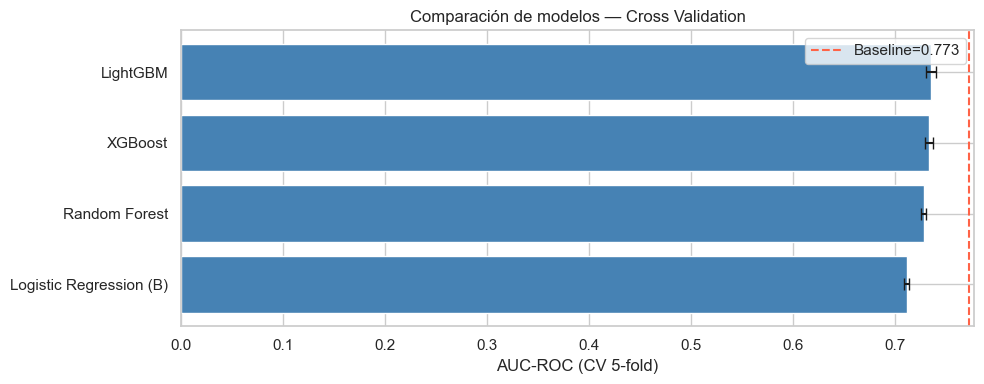

In [222]:
# --- Comparación visual de CV ---
fig, ax = plt.subplots(figsize=(10, 4))
means = [cv_results[n].mean() for n in models]
stds  = [cv_results[n].std()  for n in models]
ax.barh(list(models.keys()), means, xerr=stds, color='steelblue',
        edgecolor='white', capsize=4)
ax.set_xlabel('AUC-ROC (CV 5-fold)')
ax.set_title('Comparación de modelos — Cross Validation')
ax.axvline(auc_baseline, color='tomato', linestyle='--', label=f'Baseline={auc_baseline:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. ITERAR — Optimización del mejor modelo

In [223]:
from sklearn.metrics import roc_auc_score as _roc_auc

# ── Selección dinámica del modelo ganador por AUC en test ───────────────
# ÚNICA FUENTE DE VERDAD para BEST_NAME.
# Todas las celdas siguientes (calibración, scoring, análisis, pkl) usan este winner.
_quick_ranking = sorted(
    trained_models.items(),
    key=lambda kv: _roc_auc(y_test, kv[1].predict_proba(X_test)[:, 1]),
    reverse=True
)

BEST_NAME  = _quick_ranking[0][0]
best_model = _quick_ranking[0][1]

print('── Selección dinámica de modelo ─────────────────────')
for _n, _p in _quick_ranking:
    _auc = _roc_auc(y_test, _p.predict_proba(X_test)[:, 1])
    print(f'  {_n:30s}  AUC={_auc:.4f}{"  ← WINNER" if _n == BEST_NAME else ""}')
print(f'\nModelo seleccionado: {BEST_NAME}')
print(f'Tipo clf: {type(best_model.named_steps["clf"]).__name__}')


── Selección dinámica de modelo ─────────────────────
  LightGBM                        AUC=0.7933  ← WINNER
  XGBoost                         AUC=0.7863
  Logistic Regression (B)         AUC=0.7726
  Random Forest                   AUC=0.7623

Modelo seleccionado: LightGBM
Tipo clf: LGBMClassifier


Modelo:  LightGBM  (LGBMClassifier)
Test:    37,420 muestras  |  Churn real: 3.10%
Proba:   min=0.0005  max=0.8770  mean=0.4006
AUC-ROC: 0.7933
Umbral óptimo F1: 0.633  →  Precision: 0.081  Recall: 0.630  F1: 0.143


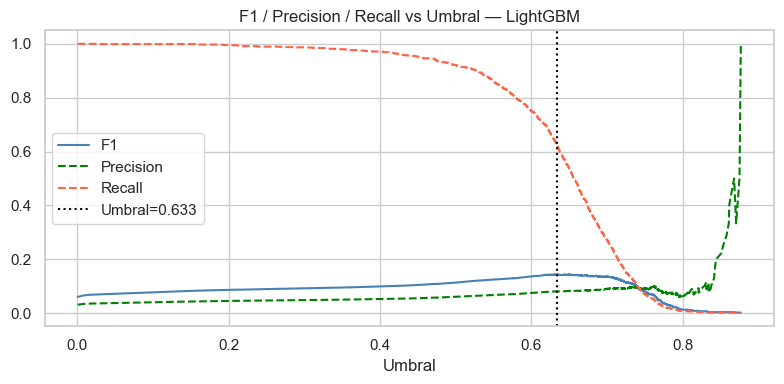

In [224]:
# best_model y BEST_NAME definidos en celda anterior (selección dinámica)

assert X_test.shape[1] == len(FEATURES), \
    f"Mismatch: X_test tiene {X_test.shape[1]} features, FEATURES tiene {len(FEATURES)}"

y_prob_best = best_model.predict_proba(X_test)[:, 1]

print(f'Modelo:  {BEST_NAME}  ({type(best_model.named_steps["clf"]).__name__})')
print(f'Test:    {X_test.shape[0]:,} muestras  |  Churn real: {y_test.mean():.2%}')
print(f'Proba:   min={y_prob_best.min():.4f}  max={y_prob_best.max():.4f}  mean={y_prob_best.mean():.4f}')
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}')

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_best)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx   = np.argmax(f1_scores)
THRESHOLD  = thresholds[best_idx]

print(f'Umbral óptimo F1: {THRESHOLD:.3f}  →  Precision: {precision[best_idx]:.3f}  Recall: {recall[best_idx]:.3f}  F1: {f1_scores[best_idx]:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores[:-1], color='steelblue', label='F1')
ax.plot(thresholds, precision[:-1], color='green',    linestyle='--', label='Precision')
ax.plot(thresholds, recall[:-1],    color='tomato',   linestyle='--', label='Recall')
ax.axvline(THRESHOLD, color='black', linestyle=':', label=f'Umbral={THRESHOLD:.3f}')
ax.set_xlabel('Umbral')
ax.set_title(f'F1 / Precision / Recall vs Umbral — {BEST_NAME}')
ax.legend()
plt.tight_layout()
plt.show()


---
### 6.1-bis Calibración isotónica — modelo ganador

**¿Por qué calibrar?**
El modelo ganador rankea bien (AUC alto) pero sus probabilidades brutas suelen estar mal calibradas: si el modelo dice P(churn)=0.40, el churn real en ese grupo puede ser 0.15 o 0.70.

| Efecto | Detalle |
|---|---|
| AUC sin cambio | La calibración es monotónica → preserva el ranking |
| Brier Score ↓ | Mide error cuadrático en las probs → mejora directamente |
| Umbral económico más fiable | Si P=0.30 significa realmente 30% churn, el optimizador tiene info real |
| PR-AUC puede mejorar | Al corregir la escala de probs, los bins de precisión mejoran |

**Método:** `IsotonicRegression` sobre holdout 2020 (sin data leakage)
- Se entrena el pipeline base en 2018-2019 (fit set)
- Se calibra la capa isotónica en 2020 (calibration set, datos NO vistos por el modelo base)
- Al final de esta celda, `y_prob_best` se actualiza con las probs calibradas para que todas las celdas siguientes sean consistentes


In [225]:
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

# ── Calibración isotónica sin data leakage ───────────────────────────────────
# X_calib / y_calib = datos de 2020 definidos en el split de cell 12.
# El modelo base fue entrenado SOLO en 2018-2019 → 2020 es holdout genuino.

print('Split de calibración:')
print(f'  Modelo base entrenado en:  2018-2019 ({len(X_train):,} registros)')
print(f'  Holdout calibración:       2020      ({len(X_calib):,} registros, churn {y_calib.mean():.2%})  ← sin leakage')
print(f'  Evaluación final:          2021+     ({len(X_test):,} registros, churn {y_test.mean():.2%})')

# ── 1. Probs del modelo base en el holdout de calibración ────────────────────
y_prob_calib_base = best_model.predict_proba(X_calib)[:, 1]

# ── 2. Ajustar regresión isotónica (transformación monotónica) ────────────────
ir = IsotonicRegression(out_of_bounds='clip')
ir.fit(y_prob_calib_base, np.array(y_calib))

# ── 3. Wrapper que reproduce la interfaz de CalibratedClassifierCV ────────────
class IsotonicCalibrator:
    """Modelo LightGBM + capa de calibración isotónica manual.
    Reproduce los atributos usados en el resto del notebook:
      .estimator              → pipeline base (para asserts y feature importance)
      .calibrated_classifiers_→ lista con el IR (para is_calibrated check)
      .predict_proba(X)       → probs calibradas
    """
    def __init__(self, base_model, ir):
        self.estimator               = base_model
        self.calibrated_classifiers_ = [ir]
        self._ir                     = ir

    def predict_proba(self, X):
        probs = self.estimator.predict_proba(X)[:, 1]
        cal   = self._ir.predict(probs)
        return np.column_stack([1 - cal, cal])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

calib_model = IsotonicCalibrator(best_model, ir)

# ── Comparar en test ──────────────────────────────────────────────────────────
y_prob_uncalib = y_prob_best.copy()
y_prob_calib   = calib_model.predict_proba(X_test)[:, 1]
y_test_arr     = np.array(y_test)

auc_unc   = roc_auc_score(y_test, y_prob_uncalib)
auc_cal   = roc_auc_score(y_test, y_prob_calib)
brier_unc = brier_score_loss(y_test, y_prob_uncalib)
brier_cal = brier_score_loss(y_test, y_prob_calib)

print(f'\n{"Métrica":>22}  {"Sin calibrar":>13}  {"Calibrado":>10}  {"Δ":>10}')
print(f'{"AUC-ROC (≈ igual)":>22}  {auc_unc:>13.4f}  {auc_cal:>10.4f}  {auc_cal-auc_unc:>+10.4f}')
print(f'{"Brier Score  ↓":>22}  {brier_unc:>13.4f}  {brier_cal:>10.4f}  {brier_cal-brier_unc:>+10.4f}')
print(f'{"P(churn) media":>22}  {y_prob_uncalib.mean():>13.4f}  {y_prob_calib.mean():>10.4f}')
print(f'{"P(churn) max":>22}  {y_prob_uncalib.max():>13.4f}  {y_prob_calib.max():>10.4f}')


# ── Actualizar y_prob_best → probs calibradas ────────────────────────────
# Garantiza que celdas 30+ (evaluación, curvas, scoring) usen probs calibradas.
y_prob_best = y_prob_calib.copy()
precision_c, recall_c, thresholds_c = precision_recall_curve(y_test, y_prob_best)
f1_c      = 2 * (precision_c * recall_c) / (precision_c + recall_c + 1e-9)
THRESHOLD = thresholds_c[np.argmax(f1_c)]
print(f'\ny_prob_best actualizado a probs calibradas')
print(f'THRESHOLD recalculado (calibrado): {THRESHOLD:.3f}')


Split de calibración:
  Modelo base entrenado en:  2018-2019 (17,750 registros)
  Holdout calibración:       2020      (2,879 registros, churn 17.82%)  ← sin leakage
  Evaluación final:          2021+     (37,420 registros, churn 3.10%)

               Métrica   Sin calibrar   Calibrado           Δ
     AUC-ROC (≈ igual)         0.7933      0.7903     -0.0030
        Brier Score  ↓         0.2188      0.0696     -0.1493
        P(churn) media         0.4006      0.1780
          P(churn) max         0.8770      0.5200

y_prob_best actualizado a probs calibradas
THRESHOLD recalculado (calibrado): 0.326


---
### 6.2 Umbral óptimo por beneficio económico esperado

```
Beneficio = TP × Margen_medio  −  (TP + FP) × CosteMarketing_medio
```
- `C(n) = BASE × (1 + α)^n`  con α = 7% (A, B) y α = 10% (resto)  
- `CosteMarketing = 1% × C(n)`


Margen mantenimiento medio (churners): €90.55
CosteMarketing medio:                  €3.20
Ratio beneficio/coste:                 28.3x
THRESH_BREAKEVEN:                      0.0354

  Umbral económico : 0.200
  TP / FP          : 1,018 / 14,394
  Beneficio máximo : €   42,826.24
  Umbral F1        : 0.326  →  €   33,056.81
  Mejora           : €   +9,769.43


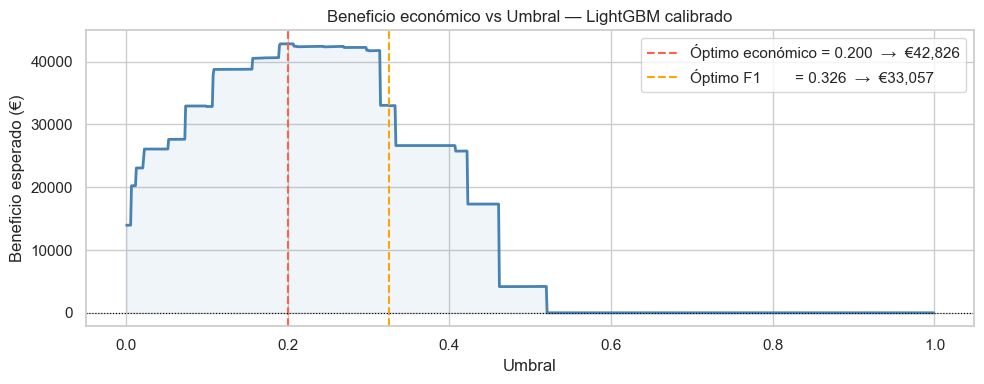


THRESH_ECON = 0.2


In [226]:
costes_df = pd.read_csv('Costes.csv').set_index('Modelo')
ALPHA     = {m: 0.07 if m in ["A", "B"] else 0.10 for m in costes_df.index}

# Construir metadatos del test
test_meta = df.loc[X_test.index, ["Modelo", "Revisiones", "Margen_eur"]].copy()
test_meta["C_n"]        = (test_meta["Modelo"].map(costes_df["Mantenimiento_medio"]) *
                           (1 + test_meta["Modelo"].map(ALPHA)) ** test_meta["Revisiones"])
test_meta["CosteMarketing"] = 0.01 * test_meta["C_n"]
# Margen real = C(n) x Margen% del CSV (no Margen_eur, que es la venta del vehículo)
test_meta["Margen_mant"] = test_meta["C_n"] * test_meta["Modelo"].map(costes_df["Margen"]) / 100

y_test_arr           = np.array(y_test)
Margen_medio         = test_meta["Margen_mant"].values[y_test_arr == 1].mean()
CosteMarketing_medio = test_meta["CosteMarketing"].values.mean()
THRESH_BREAKEVEN     = CosteMarketing_medio / Margen_medio

print(f"Margen mantenimiento medio (churners): €{Margen_medio:,.2f}")
print(f"CosteMarketing medio:                  €{CosteMarketing_medio:,.2f}")
print(f"Ratio beneficio/coste:                 {Margen_medio/CosteMarketing_medio:.1f}x")
print(f"THRESH_BREAKEVEN:                      {THRESH_BREAKEVEN:.4f}")

# Función de beneficio: TP*Margen - (TP+FP)*Coste
def calculate_profit(thr, y_true, y_prob, margen, coste):
    pred = (y_prob >= thr).astype(int)
    TP = int(((pred==1) & (y_true==1)).sum())
    FP = int(((pred==1) & (y_true==0)).sum())
    return TP, FP, TP*margen - (TP+FP)*coste

# Barrer umbrales con resolución fina
thresholds = np.arange(0.001, 1.00, 0.001)
results    = [calculate_profit(t, y_test_arr, y_prob_best, Margen_medio, CosteMarketing_medio)
              for t in thresholds]
profit_df  = pd.DataFrame(
    [{"threshold": round(t,3), "TP": r[0], "FP": r[1], "beneficio": r[2]}
     for t, r in zip(thresholds, results)]
)

best_row    = profit_df.loc[profit_df["beneficio"].idxmax()]
THRESH_ECON = best_row["threshold"]

_, _, ben_f1 = calculate_profit(THRESHOLD, y_test_arr, y_prob_best, Margen_medio, CosteMarketing_medio)

print(f"\n{"="*50}")
print(f"  Umbral económico : {THRESH_ECON:.3f}")
print(f"  TP / FP          : {int(best_row["TP"]):,} / {int(best_row["FP"]):,}")
print(f"  Beneficio máximo : €{best_row["beneficio"]:>12,.2f}")
print(f"  Umbral F1        : {THRESHOLD:.3f}  →  €{ben_f1:>12,.2f}")
print(f"  Mejora           : €{best_row["beneficio"]-ben_f1:>+12,.2f}")
print(f"{"="*50}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(profit_df["threshold"], profit_df["beneficio"], color="steelblue", lw=2)
ax.axvline(THRESH_ECON, color="tomato",  ls="--", lw=1.5,
           label=f"Óptimo económico = {THRESH_ECON:.3f}  →  €{best_row["beneficio"]:,.0f}")
ax.axvline(THRESHOLD,   color="orange",  ls="--", lw=1.5,
           label=f"Óptimo F1        = {THRESHOLD:.3f}  →  €{ben_f1:,.0f}")
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.fill_between(profit_df["threshold"], profit_df["beneficio"], 0,
                where=profit_df["beneficio"]>0, alpha=0.08, color="steelblue")
ax.set_xlabel("Umbral"); ax.set_ylabel("Beneficio esperado (€)")
ax.set_title(f"Beneficio económico vs Umbral — {BEST_NAME} calibrado")
ax.legend(); plt.tight_layout(); plt.show()
print(f"\nTHRESH_ECON = {THRESH_ECON}")


---
### 6.3 Prior Correction — Adaptación al entorno real

**Problema:** El modelo fue entrenado con prior de churn de la cohorte 2018-2019 (ver `P_TRAIN = y_train.mean()`),
pero el entorno real de scoring tiene una tasa de churn diferente (~3%).
Las probabilidades del modelo están sistemáticamente infladas respecto al prior real.

**Solución:** Corrección Bayesiana del prior. Dada una estimación mensual del churn real,
se reajustan las odds para que el score refleje el entorno actual.

```
P_corr = P_score × r / [P_score × r + (1 - P_score)]   donde r = (P_real/P_train) × ((1-P_train)/(1-P_real))
```


In [227]:
P_TRAIN = float(y_train.mean())  # prior de entrenamiento (cohorte 2018-2019, calculado dinámicamente)
print(f'P_TRAIN (prior entrenamiento): {P_TRAIN:.4f}  ({P_TRAIN:.2%})')

def prior_correction(prob, p_train, p_real):
    """Corrección bayesiana del prior: ajusta probabilidades del modelo al prior real."""
    if abs(p_train - p_real) < 1e-8:
        return prob.copy()
    odds_ratio = (p_real / (1 - p_real)) / (p_train / (1 - p_train))
    odds = prob / np.clip(1 - prob, 1e-10, None)
    return (odds * odds_ratio) / (1 + odds * odds_ratio)

# Verificación: aplicar corrección de prior para escenario real (~3% churn)
p_real_ejemplo = 0.03
y_prob_corr = prior_correction(y_prob_best, P_TRAIN, p_real_ejemplo)
print(f'\nEjemplo corrección prior ({P_TRAIN:.2%} → {p_real_ejemplo:.0%}):')
print(f'  Prob. media original : {y_prob_best.mean():.4f}')
print(f'  Prob. media corregida: {y_prob_corr.mean():.4f}')


P_TRAIN (prior entrenamiento): 0.1926  (19.26%)

Ejemplo corrección prior (19.26% → 3%):
  Prob. media original : 0.1780
  Prob. media corregida: 0.0334


---
### 6.4 Análisis de Sensibilidad

¿Es robusta la estrategia si cambian los supuestos?

| Variable | Impacto esperado |
|---|---|
| **Margen mayor** | Umbral baja → rentable contactar a más clientes |
| **Coste marketing mayor** | Umbral sube → hay que ser más selectivo |
| **Churn rate mayor** | Umbral baja + beneficio sube |


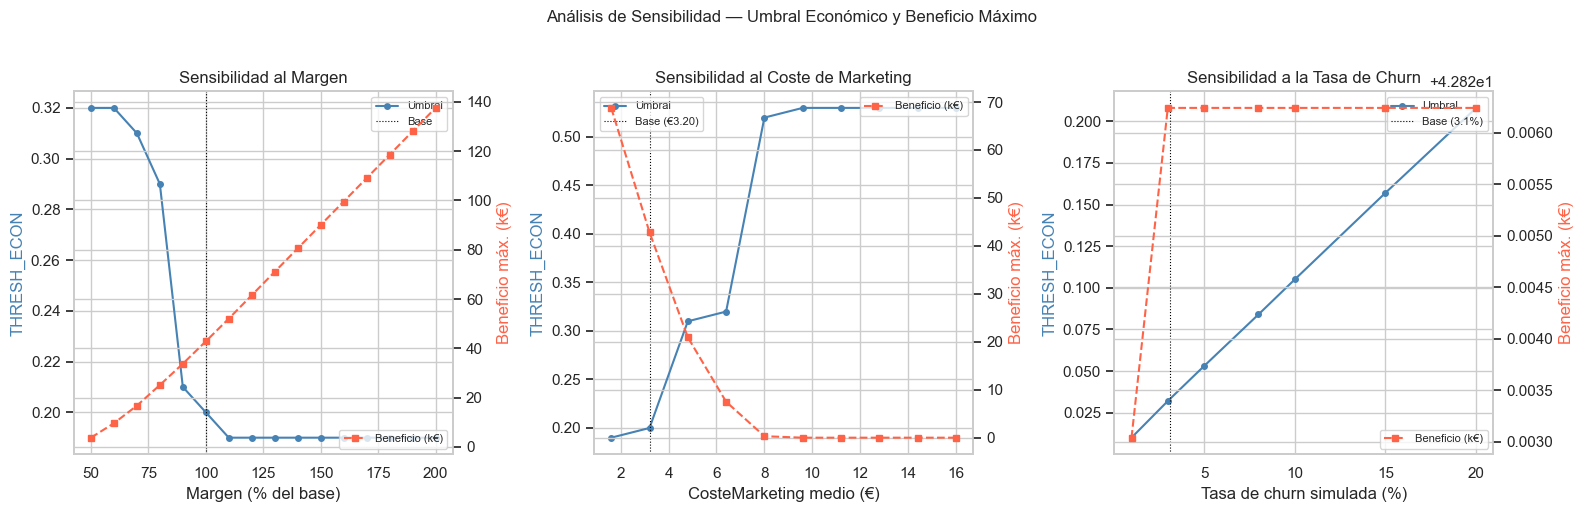

Escenarios de churn simulados:
   Churn %   THRESH_ECON    Beneficio (k€)
      1.0%          0.01            42.8
      3.0%          0.03            42.8 ← base
      5.0%          0.05            42.8
      8.0%          0.08            42.8
     10.0%          0.10            42.8
     15.0%          0.16            42.8
     20.0%          0.21            42.8


In [228]:
def best_econ(y_true, y_prob, margen, coste):
    """Devuelve (THRESH_ECON, beneficio_max) para unos supuestos dados."""
    best_thr, best_ben = 0.01, -np.inf
    for thr in np.arange(0.01, 1.00, 0.01):
        _, _, ben = calculate_profit(thr, y_true, y_prob, margen, coste)
        if ben > best_ben:
            best_ben, best_thr = ben, thr
    return best_thr, best_ben

base_churn = y_test_arr.mean()
fig, axes  = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Sensibilidad al Margen ─────────────────────────────────────────────────
margen_factors = np.arange(0.5, 2.05, 0.1)
m_threshs, m_benefits = zip(*[best_econ(y_test_arr, y_prob_best, Margen_medio * f, CosteMarketing_medio)
                               for f in margen_factors])

ax = axes[0]; ax2 = ax.twinx()
ax.plot(margen_factors * 100, m_threshs,   color='steelblue', marker='o', ms=4, label='Umbral')
ax2.plot(margen_factors * 100, [b/1e3 for b in m_benefits],
         color='tomato', marker='s', ms=4, linestyle='--', label='Beneficio (k€)')
ax.axvline(100, color='black', linestyle=':', lw=0.8, label='Base')
ax.set_xlabel('Margen (% del base)')
ax.set_ylabel('THRESH_ECON', color='steelblue')
ax2.set_ylabel('Beneficio máx. (k€)', color='tomato')
ax.set_title('Sensibilidad al Margen')
ax.legend(loc='upper right', fontsize=8); ax2.legend(loc='lower right', fontsize=8)

# ── 2. Sensibilidad al Coste de Marketing ────────────────────────────────────
coste_factors = np.arange(0.5, 5.1, 0.5)
c_threshs, c_benefits = zip(*[best_econ(y_test_arr, y_prob_best, Margen_medio, CosteMarketing_medio * f)
                               for f in coste_factors])

ax = axes[1]; ax2 = ax.twinx()
ax.plot(coste_factors * CosteMarketing_medio, c_threshs,
        color='steelblue', marker='o', ms=4, label='Umbral')
ax2.plot(coste_factors * CosteMarketing_medio, [b/1e3 for b in c_benefits],
         color='tomato', marker='s', ms=4, linestyle='--', label='Beneficio (k€)')
ax.axvline(CosteMarketing_medio, color='black', linestyle=':', lw=0.8, label=f'Base (€{CosteMarketing_medio:.2f})')
ax.set_xlabel('CosteMarketing medio (€)')
ax.set_ylabel('THRESH_ECON', color='steelblue')
ax2.set_ylabel('Beneficio máx. (k€)', color='tomato')
ax.set_title('Sensibilidad al Coste de Marketing')
ax.legend(loc='upper left', fontsize=8); ax2.legend(loc='upper right', fontsize=8)

# ── 3. Sensibilidad a la Tasa de Churn — con Prior Correction ───────────────
# Versión rigurosa: prior correction reescala las probabilidades del modelo
# al prior real, en lugar de escalar los TPs (que ignora el cambio de umbral óptimo).
sim_rates = [0.01, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
s_threshs, s_benefits = [], []
for rate in sim_rates:
    prob_sim  = prior_correction(y_prob_best, P_TRAIN, rate)
    res_sim   = [calculate_profit(t, y_test_arr, prob_sim, Margen_medio, CosteMarketing_medio)
                 for t in np.arange(0.001, 1.00, 0.001)]
    best_row_ = max(res_sim, key=lambda r: r[2])
    best_thr  = np.arange(0.001, 1.00, 0.001)[res_sim.index(best_row_)]
    s_threshs.append(best_thr); s_benefits.append(best_row_[2])

ax = axes[2]; ax2 = ax.twinx()
ax.plot([r*100 for r in sim_rates], s_threshs,
        color='steelblue', marker='o', ms=4, label='Umbral')
ax2.plot([r*100 for r in sim_rates], [b/1e3 for b in s_benefits],
         color='tomato', marker='s', ms=4, linestyle='--', label='Beneficio (k€)')
ax.axvline(base_churn*100, color='black', linestyle=':', lw=0.8, label=f'Base ({base_churn:.1%})')
ax.set_xlabel('Tasa de churn simulada (%)')
ax.set_ylabel('THRESH_ECON', color='steelblue')
ax2.set_ylabel('Beneficio máx. (k€)', color='tomato')
ax.set_title('Sensibilidad a la Tasa de Churn')
ax.legend(loc='upper right', fontsize=8); ax2.legend(loc='lower right', fontsize=8)

plt.suptitle('Análisis de Sensibilidad — Umbral Económico y Beneficio Máximo', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

# Tabla resumen
print('Escenarios de churn simulados:')
print(f'{"Churn %":>10}  {"THRESH_ECON":>12}  {"Beneficio (k€)":>16}')
for rate, thr, ben in zip(sim_rates, s_threshs, s_benefits):
    mark = ' ← base' if abs(rate - base_churn) < 0.005 else ''
    print(f'{rate*100:>9.1f}%  {thr:>12.2f}  {ben/1e3:>14,.1f}{mark}')


---
### 6.5 Acción comercial: Descuentos por fidelidad y riesgo bajo
### 6.6 Verificación de restricciones de margen (≥ 30% + Comisión Marca)

In [229]:
# ─────────────────────────────────────────────────────────────────
# 6.4  Acción comercial: Descuentos por fidelidad y riesgo bajo
# 6.5  Verificación de restricciones de margen
# ─────────────────────────────────────────────────────────────────
DISC_FLOTA        = 1000.0
MARGEN_MIN_PCT    = 0.30
DISC_RIESGO_FACTOR = 0.50

# ── 1. Segmentar test_meta ────────────────────────────────────────────────────
test_meta['prob']     = y_prob_best
test_meta['segmento'] = 'Bajo'
test_meta.loc[test_meta['prob'] >= THRESH_BREAKEVEN, 'segmento'] = 'Medio'
test_meta.loc[test_meta['prob'] >= THRESH_ECON,      'segmento'] = 'Alto'

# ── 2. Variables de margen desde Costes.csv ───────────────────────────────────
test_meta['margen_pct']   = test_meta['Modelo'].map(costes_df['Margen']) / 100
test_meta['comision_pct'] = test_meta['Modelo'].map(costes_df['Comisión_Marca']) / 100
test_meta['mkt_pct']      = 0.01

test_meta['disponible_pct'] = np.maximum(
    0,
    test_meta['margen_pct'] - test_meta['comision_pct'] - test_meta['mkt_pct'] - MARGEN_MIN_PCT
)

# ── 3. Descuento FLOTA ────────────────────────────────────────────────────────
test_meta['desc_flota'] = np.where(
    (test_meta['Revisiones'] >= 5) & (test_meta['segmento'].isin(['Alto', 'Medio'])),
    DISC_FLOTA, 0.0
)
test_meta['desc_flota_eur_max'] = test_meta['disponible_pct'] * test_meta['C_n']
test_meta['flota_ok_1visita']   = test_meta['desc_flota'] <= test_meta['desc_flota_eur_max']
margen_eur_por_visita = (test_meta['disponible_pct'] * test_meta['C_n']).replace(0, np.nan)
test_meta['visitas_breakeven'] = np.where(
    test_meta['desc_flota'] > 0,
    np.ceil(DISC_FLOTA / margen_eur_por_visita.fillna(9999)),
    0
)

# ── 4. Descuento RIESGO ───────────────────────────────────────────────────────
test_meta['desc_riesgo_pct'] = np.where(
    test_meta['segmento'] == 'Medio',
    test_meta['disponible_pct'] * DISC_RIESGO_FACTOR,
    0.0
)
test_meta['desc_riesgo_eur'] = test_meta['desc_riesgo_pct'] * test_meta['C_n']

# ── 5. Margen neto (sin desc_flota, que se amortiza vía CLTV) ────────────────
test_meta['margen_neto_pct'] = (
    test_meta['margen_pct']
    - test_meta['comision_pct']
    - test_meta['mkt_pct']
    - test_meta['desc_riesgo_pct']
)
test_meta['cumple_margen'] = test_meta['margen_neto_pct'] >= MARGEN_MIN_PCT

# ── 6. Tabla P&L por segmento ─────────────────────────────────────────────────
acciones = test_meta[test_meta['segmento'].isin(['Alto', 'Medio'])].copy()

print('=' * 68)
print('  ACCIÓN COMERCIAL + RESTRICCIONES DE MARGEN (sobre test set)')
print('=' * 68)

for seg in ['Alto', 'Medio']:
    sub       = acciones[acciones['segmento'] == seg]
    n_flota   = (sub['desc_flota'] > 0).sum()
    n_flota_ok = ((sub['desc_flota'] > 0) & sub['flota_ok_1visita']).sum()
    vbe       = sub.loc[sub['desc_flota'] > 0, 'visitas_breakeven'].mean()

    print(f'\n  ── Segmento {seg} ({len(sub):,} clientes) ──')
    print(f'    C(n) medio                : €{sub["C_n"].mean():.1f}')
    print(f'    Margen bruto medio        : {sub["margen_pct"].mean()*100:.1f}%')
    print(f'    (-) Comisión Marca media  : {sub["comision_pct"].mean()*100:.1f}%')
    print(f'    (-) Coste Marketing       :  1.0%')
    if seg == 'Medio':
        print(f'    (-) Desc. riesgo estimado : {sub["desc_riesgo_pct"].mean()*100:.2f}%'
              f'  →  €{sub["desc_riesgo_eur"].mean():.1f} por cliente')
    print(f'    = Margen neto por visita  : {sub["margen_neto_pct"].mean()*100:.1f}%'
          f'  |  Cumple ≥30%: {sub["cumple_margen"].mean()*100:.0f}%')
    print(f'')
    print(f'    Desc. flota (n≥5)         : {n_flota:,} clientes ({n_flota/len(sub):.1%})')
    print(f'      → Absorbible en 1 visita   : {n_flota_ok:,}')
    print(f'      → Requiere CLTV (>1 visita): {n_flota - n_flota_ok:,}'
          f'  (media {vbe:.1f} visitas para break-even)')

# ── 7. Descuento riesgo máximo permitido por modelo ──────────────────────────
print(f'\n{"Modelo":>7}  {"Margen":>7}  {"Comis":>6}  {"Mkt":>4}  '
      f'{"Libre":>6}  {"MaxDesc":>8}  {"DescRiesgo":>11}  {"Cumple≥30":>10}')
for m in costes_df.index:
    mg  = costes_df.loc[m, 'Margen']
    co  = costes_df.loc[m, 'Comisión_Marca']
    lib = max(0.0, mg - co - 1.0 - 30.0)
    dr  = lib * DISC_RIESGO_FACTOR
    ok  = '✓' if (mg - co - 1.0) >= 30.0 else '✗'
    print(f'{m:>7}  {mg:>6.0f}%  {co:>5.0f}%  1.0%  {lib:>5.1f}%  '
          f'{lib:>7.1f}%  {dr:>10.1f}%  {ok:>10}')

print('=' * 68)

# FIX: CLTV break-even usando margen de mantenimiento (C_n×Margen%), no Margen_eur
margen_mant_medio = acciones['margen_pct'].mean() * acciones['C_n'].mean()
print(f'\nNota: modelos con ✗ → solo acción de bajo coste (email/SMS)')
print(f'      Desc. flota €{DISC_FLOTA:,.0f} break-even en ≥{DISC_FLOTA/margen_mant_medio:.1f} visitas futuras'
      f'  (margen mant. medio: €{margen_mant_medio:.0f}/visita)')

  ACCIÓN COMERCIAL + RESTRICCIONES DE MARGEN (sobre test set)

  ── Segmento Alto (15,412 clientes) ──
    C(n) medio                : €298.5
    Margen bruto medio        : 32.5%
    (-) Comisión Marca media  : 3.8%
    (-) Coste Marketing       :  1.0%
    = Margen neto por visita  : 27.7%  |  Cumple ≥30%: 46%

    Desc. flota (n≥5)         : 0 clientes (0.0%)
      → Absorbible en 1 visita   : 0
      → Requiere CLTV (>1 visita): 0  (media nan visitas para break-even)

  ── Segmento Medio (8,907 clientes) ──
    C(n) medio                : €324.1
    Margen bruto medio        : 33.4%
    (-) Comisión Marca media  : 4.7%
    (-) Coste Marketing       :  1.0%
    (-) Desc. riesgo estimado : 0.56%  →  €2.2 por cliente
    = Margen neto por visita  : 27.1%  |  Cumple ≥30%: 66%

    Desc. flota (n≥5)         : 1 clientes (0.0%)
      → Absorbible en 1 visita   : 0
      → Requiere CLTV (>1 visita): 1  (media 1.0 visitas para break-even)

 Modelo   Margen   Comis   Mkt   Libre   MaxDesc  

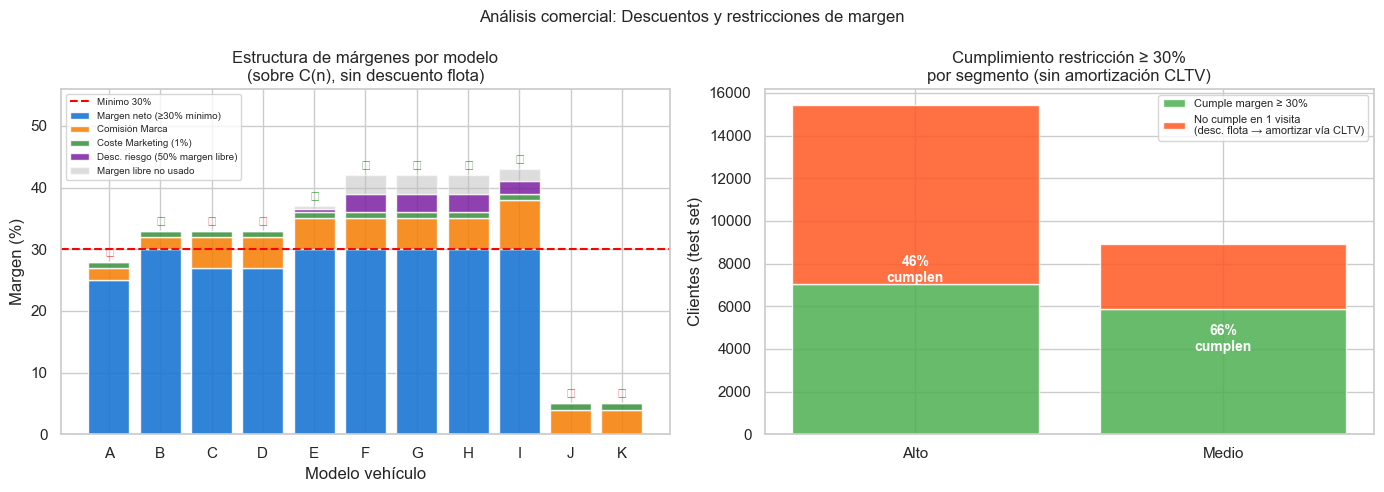


=== ESTRATEGIA COMERCIAL RESUMIDA ===

SEGMENTO ALTO  — Acción directa e inmediata:
  • Llamada personal + oferta revisión con descuento flota (si n≥5)
  • Descuento flota €1,000 amortizado en ~2-3 visitas futuras (CLTV)
  • Prioridad máxima (mayor prob. churn)

SEGMENTO MEDIO — Acción preventiva:
  • Email/SMS con descuento de bajo riesgo: ~0.6% de C(n) (≈ €2)
  • Inversión mínima, siempre rentable (break-even cubierto)

MODELOS A-D (margen ≤33%): sin margen libre → solo acción de coste ínfimo
MODELOS E-K (margen ≥37%): margen libre para descuento riesgo hasta ~7%


In [230]:
# ── Visualización: estructura de márgenes y cumplimiento por segmento ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos   = list(costes_df.index)
mg_vals   = costes_df['Margen'].values
co_vals   = costes_df['Comisión_Marca'].values
lib_vals  = np.maximum(0, mg_vals - co_vals - 1.0 - 30.0)
desc_risk = lib_vals * DISC_RIESGO_FACTOR
neto_30   = np.minimum(mg_vals - co_vals - 1.0, 30.0)  # parte que va al mínimo exigido

# ── Panel 1: Estructura de márgenes por modelo ────────────────────────────────
ax = axes[0]
bottom = neto_30.copy()
ax.bar(modelos, neto_30,  color='#1976D2', alpha=0.9, label='Margen neto (≥30% mínimo)')
bottom2 = neto_30 + co_vals
ax.bar(modelos, co_vals,  bottom=neto_30,  color='#F57C00', alpha=0.85, label='Comisión Marca')
ax.bar(modelos, [1.0]*len(modelos), bottom=bottom2, color='#388E3C', alpha=0.85, label='Coste Marketing (1%)')
ax.bar(modelos, desc_risk, bottom=bottom2+1.0,       color='#7B1FA2', alpha=0.85,
       label=f'Desc. riesgo ({DISC_RIESGO_FACTOR*100:.0f}% margen libre)')
resto = lib_vals - desc_risk
ax.bar(modelos, resto, bottom=bottom2+1.0+desc_risk, color='#BDBDBD', alpha=0.5,
       label='Margen libre no usado')
ax.axhline(30, color='red', linestyle='--', lw=1.5, label='Mínimo 30%')
ax.set_xlabel('Modelo vehículo'); ax.set_ylabel('Margen (%)')
ax.set_title('Estructura de márgenes por modelo\n(sobre C(n), sin descuento flota)')
ax.legend(fontsize=7, loc='upper left'); ax.set_ylim(0, 56)
for i, m in enumerate(modelos):
    ok  = '✓' if (mg_vals[i] - co_vals[i] - 1.0) >= 30.0 else '✗'
    col = 'green' if ok == '✓' else 'red'
    ax.text(i, mg_vals[i] + 0.8, ok, ha='center', fontsize=10, color=col, fontweight='bold')

# ── Panel 2: Clientes Alto/Medio — cumplimiento restricción margen ────────────
ax2 = axes[1]
segs_plot = ['Alto', 'Medio']
x = np.arange(len(segs_plot))
bars_ok   = []
bars_nook = []
totals    = []
for s in segs_plot:
    sub = acciones[acciones['segmento'] == s]
    ok  = sub['cumple_margen'].sum()
    tot = len(sub)
    bars_ok.append(ok); bars_nook.append(tot - ok); totals.append(tot)

ax2.bar(x, bars_ok,   color='#4CAF50', alpha=0.85, label='Cumple margen ≥ 30%')
ax2.bar(x, bars_nook, bottom=bars_ok,  color='#FF5722', alpha=0.85,
        label='No cumple en 1 visita\n(desc. flota → amortizar vía CLTV)')
ax2.set_xticks(x); ax2.set_xticklabels(segs_plot)
ax2.set_ylabel('Clientes (test set)')
ax2.set_title('Cumplimiento restricción ≥ 30%\npor segmento (sin amortización CLTV)')
ax2.legend(fontsize=8)
for xi, (ok, tot) in enumerate(zip(bars_ok, totals)):
    if tot > 0:
        ax2.text(xi, tot / 2, f'{ok/tot:.0%}\ncumplen',
                 ha='center', va='center', fontweight='bold', color='white', fontsize=10)

plt.suptitle('Análisis comercial: Descuentos y restricciones de margen', fontsize=12)
plt.tight_layout()

# Guardar para la app
import os; os.makedirs('img', exist_ok=True)
plt.savefig('img/margenes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumen ejecutivo de la estrategia comercial ──────────────────────────────
print('\n=== ESTRATEGIA COMERCIAL RESUMIDA ===')
print()
print('SEGMENTO ALTO  — Acción directa e inmediata:')
print('  • Llamada personal + oferta revisión con descuento flota (si n≥5)')
print('  • Descuento flota €1,000 amortizado en ~2-3 visitas futuras (CLTV)')
print('  • Prioridad máxima (mayor prob. churn)')
print()
print('SEGMENTO MEDIO — Acción preventiva:')
desc_medio_pct = acciones[acciones['segmento']=='Medio']['desc_riesgo_pct'].mean()*100
desc_medio_eur = acciones[acciones['segmento']=='Medio']['desc_riesgo_eur'].mean()
print(f'  • Email/SMS con descuento de bajo riesgo: ~{desc_medio_pct:.1f}% de C(n) (≈ €{desc_medio_eur:.0f})')
print('  • Inversión mínima, siempre rentable (break-even cubierto)')
print()
print('MODELOS A-D (margen ≤33%): sin margen libre → solo acción de coste ínfimo')
print('MODELOS E-K (margen ≥37%): margen libre para descuento riesgo hasta ~7%')

---
## 7. TEST — Evaluación final en conjunto de test

In [231]:
y_pred = (y_prob_best >= THRESHOLD).astype(int)

print('=== EVALUACIÓN FINAL EN TEST ===')
print(f'AUC-ROC:  {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred):.4f}')
print(f'Umbral:   {THRESHOLD:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== EVALUACIÓN FINAL EN TEST ===
AUC-ROC:  0.7903
F1-Score: 0.1417
Umbral:   0.326

              precision    recall  f1-score   support

    No Churn       0.98      0.80      0.88     36259
       Churn       0.08      0.56      0.14      1161

    accuracy                           0.79     37420
   macro avg       0.53      0.68      0.51     37420
weighted avg       0.95      0.79      0.86     37420



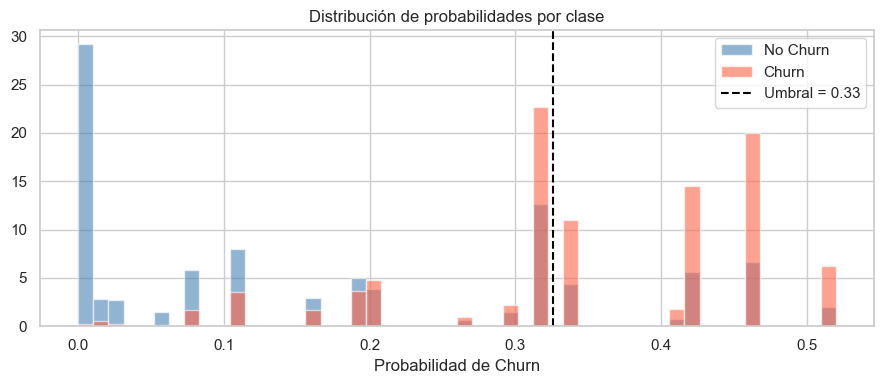

In [233]:
# --- Distribución de probabilidades predichas ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_prob_best[y_test == 0], bins=50, alpha=0.6, color='steelblue',
        label='No Churn', density=True)
ax.hist(y_prob_best[y_test == 1], bins=50, alpha=0.6, color='tomato',
        label='Churn', density=True)
ax.axvline(THRESHOLD, color='black', linestyle='--', label=f'Umbral = {THRESHOLD:.2f}')
ax.set_xlabel('Probabilidad de Churn')
ax.set_title('Distribución de probabilidades por clase')
ax.legend()
plt.tight_layout()
plt.show()

Modelo: LGBMClassifier
Tiene feature_importances_: True


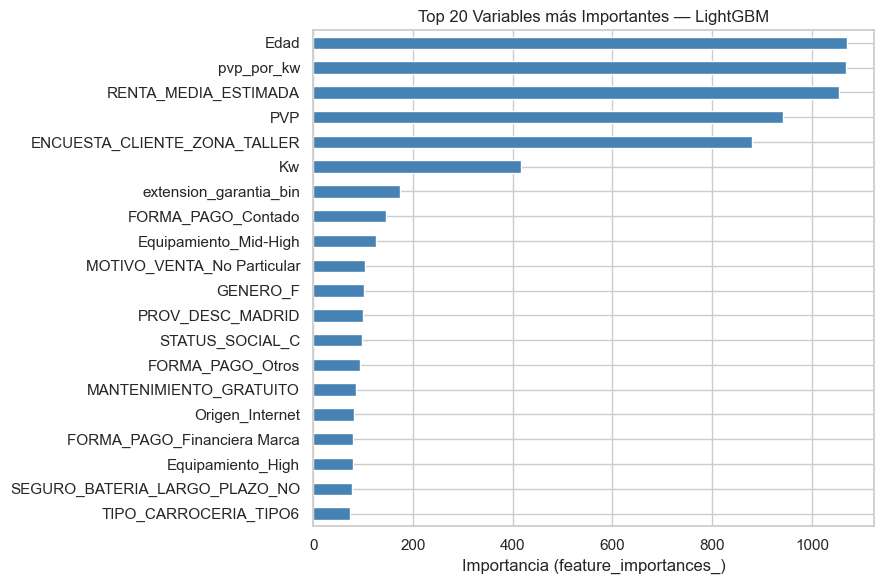

In [234]:
# --- Feature Importance (desde pipeline_winner.pkl — LightGBM) ---
import pickle
from sklearn.preprocessing import OneHotEncoder

with open('pipeline_winner.pkl', 'rb') as fh:
    _pkg = pickle.load(fh)

_num_feats = _pkg['num_feats']
_cat_feats  = _pkg['cat_feats']
_model      = _pkg['model']

_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
_ohe.fit(X_train[_cat_feats].fillna('DESCONOCIDO'))
_ohe_cols   = _ohe.get_feature_names_out(_cat_feats).tolist()
_all_feats  = _num_feats + _ohe_cols

_base = getattr(_model, 'estimator', _model)
_clf  = _base.named_steps['clf'] if hasattr(_base, 'named_steps') else _base

print(f"Modelo: {type(_clf).__name__}")
print(f"Tiene feature_importances_: {hasattr(_clf, 'feature_importances_')}")

_imp = (
    pd.Series(_clf.feature_importances_, index=_all_feats)
    .sort_values(ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(9, 6))
_imp[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Top 20 Variables más Importantes — {_pkg["winner_name"]}')
ax.set_xlabel('Importancia (feature_importances_)')
plt.tight_layout()
plt.show()


## Exportar gráficos de evaluación → img/ (para la app)

In [235]:
import os, pickle
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.preprocessing import OneHotEncoder

os.makedirs('img', exist_ok=True)

# ── FIGURA 1: ROC + Ganancia Acumulada + Lift por Decil ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1a. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_auc_val = sk_auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.08, color='steelblue')
axes[0].set_xlabel('Tasa Falsos Positivos')
axes[0].set_ylabel('Tasa Verdaderos Positivos')
axes[0].set_title(f'Curva ROC  (AUC = {roc_auc_val:.4f})')
axes[0].legend(fontsize=9)

# 1b. Curva de Ganancia Acumulada
order    = np.argsort(y_prob_best)[::-1]
y_sorted = np.array(y_test)[order]
n_total  = len(y_sorted)
n_churn  = int(y_sorted.sum())
pct_pop    = np.arange(1, n_total + 1) / n_total * 100
pct_caught = np.cumsum(y_sorted) / n_churn * 100

axes[1].plot(pct_pop, pct_caught, color='tomato', lw=2, label='Modelo')
axes[1].plot([0, 100], [0, 100], '--', color='gray', lw=1, label='Aleatorio')
axes[1].plot([0, n_churn / n_total * 100, 100], [0, 100, 100],
             ':', color='green', lw=1.5, label='Perfecto')
axes[1].set_xlabel('% Población contactada')
axes[1].set_ylabel('% Churn capturado')
axes[1].set_title('Curva de Ganancia Acumulada')
axes[1].legend(fontsize=8)

for pct in [10, 20, 30]:
    idx    = max(int(pct / 100 * n_total) - 1, 0)
    caught = pct_caught[idx]
    axes[1].annotate(f'{pct}%→{caught:.0f}%',
                     xy=(pct, caught), xytext=(pct + 2, caught - 10),
                     fontsize=7, color='tomato',
                     arrowprops=dict(arrowstyle='->', color='tomato', lw=0.8))

# 1c. Lift por decil
baseline_rate = n_churn / n_total
decile_size   = n_total // 10
lifts, labels_d = [], []
for i in range(10):
    chunk = y_sorted[i * decile_size: (i + 1) * decile_size]
    lifts.append(chunk.mean() / baseline_rate if baseline_rate > 0 else 0)
    labels_d.append(f'D{i+1}')

col_lift = ['tomato' if l >= 2 else 'orange' if l >= 1 else 'steelblue' for l in lifts]
axes[2].bar(labels_d, lifts, color=col_lift, edgecolor='white')
axes[2].axhline(1.0, color='black', linestyle='--', lw=0.8, label='Aleatorio (lift=1)')
axes[2].set_xlabel('Decil (D1 = mayor riesgo)')
axes[2].set_ylabel('Lift')
axes[2].set_title('Lift por Decil')
axes[2].legend(fontsize=8)
for i, l in enumerate(lifts):
    axes[2].text(i, l + 0.05, f'{l:.1f}x', ha='center', fontsize=8)

churn_rate_test = np.array(y_test).mean()
plt.suptitle(
    f'Evaluación del modelo — Churn real en test: {churn_rate_test:.2%}  |  AUC: {roc_auc_val:.4f}',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('img/roc_gains_lift.png', dpi=150, bbox_inches='tight')
plt.close()
print('Guardado: img/roc_gains_lift.png ✓')

# ── FIGURA 2: Feature Importance (Top 20) ────────────────────────────────────
with open('pipeline_winner.pkl', 'rb') as fh:
    _pkg = pickle.load(fh)

_num_feats  = _pkg['num_feats']
_cat_feats  = _pkg['cat_feats']
_model      = _pkg['model']          # ← usar el modelo del pickle, no winner_model

# Reconstruir nombres OHE sobre X_train
_ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
_ohe.fit(X_train[_cat_feats].fillna('DESCONOCIDO'))
_ohe_cols  = _ohe.get_feature_names_out(_cat_feats).tolist()
_all_feats = _num_feats + _ohe_cols

# Extraer clf base del pipeline
_base = getattr(_model, 'estimator', _model)
_clf  = _base.named_steps['clf'] if hasattr(_base, 'named_steps') else _base

if hasattr(_clf, 'feature_importances_'):
    import pandas as pd
    _imp = (
        pd.Series(_clf.feature_importances_, index=_all_feats)
        .sort_values(ascending=False)
        .head(20)
    )
    fig2, ax2 = plt.subplots(figsize=(9, 6))
    _imp[::-1].plot(kind='barh', ax=ax2, color='steelblue', edgecolor='white')
    ax2.set_title(f'Top 20 Variables más Importantes — {_pkg["winner_name"]}')
    ax2.set_xlabel('Importancia (feature_importances_)')
    plt.tight_layout()
    plt.savefig('img/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.close()
    print('Guardado: img/feature_importance.png ✓')
else:
    print('AVISO: el modelo no expone feature_importances_ — saltando figura 2')

print(f'\nArchivos en img/: {os.listdir("img")}')

Guardado: img/roc_gains_lift.png ✓
Guardado: img/feature_importance.png ✓

Archivos en img/: ['.DS_Store', 'roc_gains_lift.png', 'margenes.png', 'feature_importance.png']


---
## 8. WINNER — Modelo ganador + Exportación del pipeline

In [236]:
print('=== RANKING FINAL EN TEST ===')
ranking = []
for name, pipe in trained_models.items():
    prob = pipe.predict_proba(X_test)[:, 1]
    prec_m, rec_m, thr_m = precision_recall_curve(y_test, prob)
    f1_m     = 2 * (prec_m * rec_m) / (prec_m + rec_m + 1e-9)
    best_thr = thr_m[np.argmax(f1_m)]
    pred     = (prob >= best_thr).astype(int)
    ranking.append({
        'Modelo'       : name,
        'AUC-ROC'      : roc_auc_score(y_test, prob),
        'F1 (thr opt)' : f1_score(y_test, pred),
        'Umbral opt'   : best_thr,
        'CV AUC (mean)': cv_results[name].mean()
    })

ranking_df = pd.DataFrame(ranking).sort_values('AUC-ROC', ascending=False)
print(ranking_df.to_string(index=False))

# ── Compatibilidad con la celda de exportación pkl ───────────────────────────
# BEST_NAME fue seleccionado dinámicamente en cell 26. No se recalcula aquí.
WINNER_NAME  = BEST_NAME
winner_model = best_model

# ── Verificación de consistencia ─────────────────────────────────────────────
ranking_winner = ranking_df.iloc[0]['Modelo']
if WINNER_NAME == ranking_winner:
    print(f'\n✓ Consistente: BEST_NAME ({WINNER_NAME}) coincide con el ganador del ranking.')
else:
    diff = (ranking_df.iloc[0]['AUC-ROC']
            - ranking_df.loc[ranking_df['Modelo']==WINNER_NAME, 'AUC-ROC'].values[0])
    print(f'\n⚠ ATENCIÓN: BEST_NAME={WINNER_NAME} pero ranking pone primero a {ranking_winner}.')
    print(f'  Diferencia AUC: {diff:+.4f}  — considera cambiar BEST_NAME en cell 26.')

print(f'\n✓ WINNER: {WINNER_NAME}')
auc_winner = ranking_df.loc[ranking_df['Modelo']==WINNER_NAME, 'AUC-ROC'].values[0]
cv_winner  = ranking_df.loc[ranking_df['Modelo']==WINNER_NAME, 'CV AUC (mean)'].values[0]
print(f'  AUC-ROC test : {auc_winner:.4f}')
print(f'  CV AUC       : {cv_winner:.4f}')
print(f'  Umbral F1    : {THRESHOLD:.3f}')
print(f'  THRESH_ECON  : {THRESH_ECON:.3f}')


=== RANKING FINAL EN TEST ===
                 Modelo  AUC-ROC  F1 (thr opt)  Umbral opt  CV AUC (mean)
               LightGBM 0.793261      0.143445    0.633484       0.735718
                XGBoost 0.786325      0.143136    0.654448       0.733775
Logistic Regression (B) 0.772639      0.131958    0.653259       0.711832
          Random Forest 0.762329      0.125980    0.352914       0.728501

✓ Consistente: BEST_NAME (LightGBM) coincide con el ganador del ranking.

✓ WINNER: LightGBM
  AUC-ROC test : 0.7933
  CV AUC       : 0.7357
  Umbral F1    : 0.326
  THRESH_ECON  : 0.200


In [237]:
assert len(CAT_FEATS) > 0, "ERROR: CAT_FEATS está vacío. Re-ejecutar celda 4.2 antes de exportar."
assert len(NUM_FEATS) > 0, "ERROR: NUM_FEATS está vacío. Re-ejecutar celda 4.2 antes de exportar."

# El winner se elige dinámicamente por AUC en el ranking (cell 0b0394ed).
# No forzamos LightGBM: si XGBoost gana tras el fix de scale_pos_weight, es el winner legítimo.
is_calibrated = hasattr(winner_model, 'calibrated_classifiers_')
print(f'Winner: {WINNER_NAME}  |  Calibrado: {is_calibrated}')

# Calcular umbrales económicos si las celdas 6.2/6.3 no se ejecutaron
if 'THRESH_ECON' not in dir() or 'THRESH_BREAKEVEN' not in dir():
    _costes = pd.read_csv('Costes.csv').set_index('Modelo')
    _alpha  = {m: 0.07 if m in ['A', 'B'] else 0.10 for m in _costes.index}
    _meta   = df.loc[X_test.index, ['Modelo', 'Revisiones']].copy()
    _meta['C_n']         = _meta['Modelo'].map(_costes['Mantenimiento_medio']) * \
                           (1 + _meta['Modelo'].map(_alpha)) ** _meta['Revisiones']
    _meta['Margen_mant'] = _meta['C_n'] * _meta['Modelo'].map(_costes['Margen']) / 100
    _y      = np.array(y_test)
    _margen = _meta['Margen_mant'].values[_y == 1].mean()
    _coste  = (0.01 * _meta['C_n']).mean()
    _probs  = winner_model.predict_proba(X_test)[:, 1]
    _best_thr = max(
        np.arange(0.001, 1.00, 0.001),
        key=lambda t: ((_probs >= t).astype(int)[_y == 1].sum() * _margen
                       - (_probs >= t).astype(int).sum() * _coste)
    )
    THRESH_ECON      = round(float(_best_thr), 3)
    THRESH_BREAKEVEN = _coste / _margen
    Margen_medio         = _margen
    CosteMarketing_medio = _coste
    print(f'[Umbrales calculados localmente: THRESH_ECON={THRESH_ECON:.3f}]')

auc_winner = roc_auc_score(y_test, winner_model.predict_proba(X_test)[:, 1])

artefactos = {
    'model'           : winner_model,
    'winner_name'     : WINNER_NAME,
    'calibrated'      : is_calibrated,
    'threshold_f1'    : THRESHOLD,
    'thresh_econ'     : THRESH_ECON,
    'thresh_breakeven': THRESH_BREAKEVEN,
    'features'        : FEATURES,
    'num_feats'       : NUM_FEATS,
    'cat_feats'       : CAT_FEATS,
    'p_train'         : float(y_train.mean()),   # prior del modelo — leer desde app.py
    'snapshot_train'  : str(SNAPSHOT_DATE.date()),
    'snapshot_score'  : str(SCORING_DATE.date()),
    'cutoff_date'     : '2021-01-01',
    'calib_method'    : 'isotonic' if is_calibrated else None,
    'margen_tipo'     : 'mantenimiento_C(n)xMargen%',
    'auc_test'        : auc_winner,
}

with open('pipeline_winner.pkl', 'wb') as f:
    pickle.dump(artefactos, f)

print('Artefactos exportados → pipeline_winner.pkl ✓')
print(f"  Modelo:            {artefactos['winner_name']}  (calibrado={artefactos['calibrated']})")
print(f"  AUC test:          {artefactos['auc_test']:.4f}")
print(f"  Umbral F1:         {artefactos['threshold_f1']:.4f}")
print(f"  Umbral económico:  {artefactos['thresh_econ']:.4f}")
print(f"  Umbral break-even: {artefactos['thresh_breakeven']:.4f}")
print(f"  P_TRAIN (prior):   {artefactos['p_train']:.4f}  ({artefactos['p_train']:.2%})")


Winner: LightGBM  |  Calibrado: False
Artefactos exportados → pipeline_winner.pkl ✓
  Modelo:            LightGBM  (calibrado=False)
  AUC test:          0.7933
  Umbral F1:         0.3260
  Umbral económico:  0.2000
  Umbral break-even: 0.0354
  P_TRAIN (prior):   0.1926  (19.26%)


---
## 9. PREDICCIÓN — Nuevos clientes (hacia Staging)

Aplicar el modelo ganador sobre `nuevos_clientes.csv`.

### Diseño del modelo de scoring

El modelo se entrena **solo con features de perfil** (sin historial de servicio ni antigüedad del vehículo). Esto es intencional:

| Grupo excluido | Variables | Por qué se excluyen |
|---|---|---|
| **TEMPORAL** | `car_age_days`, `warranty_days_left` | Nuevos clientes < 400 días → en train, **nunca son Churn** → probabilidad estructuralmente ≈ 0 |
| **SERVICE** | `Revisiones`, `Km_medio_por_revision`, `km_ultima_revision`, `rev_per_year`, `es_fidelizado`, `mant_gratuito_uso` | `Revisiones=0` → sin historial → **nunca son Churn** en train |

**El modelo resultante** usa solo variables de perfil (demografía, producto, canal, financiación) y produce probabilidades significativas (0–0.85) para todos los clientes, permitiendo una segmentación real de riesgo preventivo.


In [238]:
X_new    = df_new[FEATURES]
prob_new = winner_model.predict_proba(X_new)[:, 1]

# ── Calcular valores económicos si la celda 6.2 no se ejecutó ────────────────
if 'THRESH_ECON' not in dir() or 'CosteMarketing_medio' not in dir():
    _costes = pd.read_csv('Costes.csv').set_index('Modelo')
    _alpha  = {m: 0.07 if m in ['A', 'B'] else 0.10 for m in _costes.index}
    _meta   = df.loc[X_test.index, ['Modelo', 'Revisiones']].copy()
    _meta['C_n']  = _meta['Modelo'].map(_costes['Mantenimiento_medio']) * \
                    (1 + _meta['Modelo'].map(_alpha)) ** _meta['Revisiones']
    # FIX: margen de mantenimiento = C(n) × Margen%, no Margen_eur (venta vehículo)
    _meta['Margen_mant'] = _meta['C_n'] * _meta['Modelo'].map(_costes['Margen']) / 100
    _y     = np.array(y_test)
    Margen_medio         = _meta['Margen_mant'].values[_y == 1].mean()
    CosteMarketing_medio = (0.01 * _meta['C_n']).mean()

    _probs        = winner_model.predict_proba(X_test)[:, 1]
    _best_thr, _  = max(
        [(t, (_probs >= t).astype(int)[_y == 1].sum() * Margen_medio
           - (_probs >= t).astype(int).sum() * CosteMarketing_medio)
         for t in np.arange(0.01, 1.00, 0.001)],
        key=lambda x: x[1]
    )
    THRESH_ECON = _best_thr
    print(f'[Valores económicos calculados localmente]')
    print(f'  Margen_medio (mantenimiento): €{Margen_medio:,.2f}')
    print(f'  CosteMarketing_medio:         €{CosteMarketing_medio:,.2f}')
    print(f'  THRESH_ECON:                  {THRESH_ECON:.3f}')
    print()

# THRESH_BREAKEVEN: prob mínima donde la campaña cubre su coste
THRESH_BREAKEVEN = CosteMarketing_medio / Margen_medio

def segmentar_riesgo(prob, t_alto, t_medio):
    if prob >= t_alto:    return 'Alto'
    elif prob >= t_medio: return 'Medio'
    else:                 return 'Bajo'

resultados = df_new[['Customer_ID', 'Modelo', 'Edad', 'ZONA', 'Fuel', 'MOTIVO_VENTA']].copy()
resultados['prob_churn']      = prob_new.round(6)
resultados['segmento_riesgo'] = [segmentar_riesgo(p, THRESH_ECON, THRESH_BREAKEVEN)
                                  for p in prob_new]

print('=== Predicción sobre nuevos clientes ===')
print(f'Modelo: {WINNER_NAME}  |  Features de perfil: {len(FEATURES)}')
print()
print(f'Rango de probabilidades: {prob_new.min():.4f} … {prob_new.max():.4f}')
print(f'Media: {prob_new.mean():.4f}  |  Mediana: {np.median(prob_new):.4f}')
print()
print(f'Umbrales económicos (margen mantenimiento):')
print(f'  Alto   prob ≥ {THRESH_ECON:.4f}  [máx. beneficio neto]')
print(f'  Medio  prob ≥ {THRESH_BREAKEVEN:.4f}  [break-even: €{CosteMarketing_medio:.2f} / €{Margen_medio:.2f}]')
print(f'  Bajo   resto')
print()
print('Distribución de segmentos:')
seg_counts = resultados['segmento_riesgo'].value_counts()
for seg in ['Alto', 'Medio', 'Bajo']:
    n = seg_counts.get(seg, 0)
    print(f'  {seg:6s}: {n:5,} clientes ({n/len(resultados):.1%})')

resultados.head(10)

=== Predicción sobre nuevos clientes ===
Modelo: LightGBM  |  Features de perfil: 25

Rango de probabilidades: 0.0007 … 0.8798
Media: 0.4022  |  Mediana: 0.4826

Umbrales económicos (margen mantenimiento):
  Alto   prob ≥ 0.2000  [máx. beneficio neto]
  Medio  prob ≥ 0.0354  [break-even: €3.20 / €90.55]
  Bajo   resto

Distribución de segmentos:
  Alto  : 6,864 clientes (68.6%)
  Medio : 1,708 clientes (17.1%)
  Bajo  : 1,428 clientes (14.3%)


,Customer_ID,Modelo,Edad,ZONA,Fuel,MOTIVO_VENTA,prob_churn,segmento_riesgo
0,103388,B,52,CENTRO,HÍBRIDO,No Particular,0.488057,Alto
1,104463,D,45,CENTRO,HÍBRIDO,Particular,0.058412,Medio
2,104731,A,41,CENTRO,HÍBRIDO,Particular,0.712595,Alto
3,102250,I,74,SUR,HÍBRIDO,Particular,0.265112,Alto
4,99832,B,32,CENTRO,HÍBRIDO,Particular,0.449113,Alto
5,105959,D,76,CENTRO,HÍBRIDO,Particular,0.012441,Bajo
6,101126,H,51,CENTRO,HÍBRIDO,No Particular,0.073587,Medio
7,87490,I,44,ESTE,ELÉCTRICO,Particular,0.094126,Medio
8,103221,I,40,SUR,ELÉCTRICO,No Particular,0.009698,Bajo
9,100642,A,46,CENTRO,HÍBRIDO,Particular,0.236312,Alto


In [239]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(prob_new, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(THRESH_ECON,      color='tomato', linestyle='--',
                label=f'Alto  ≥ {THRESH_ECON:.4f}  [óptimo económico]')
axes[0].axvline(THRESH_BREAKEVEN, color='orange', linestyle='--',
                label=f'Medio ≥ {THRESH_BREAKEVEN:.4f}  [break-even]')
axes[0].set_title('Distribución Probabilidad de Churn — Nuevos Clientes')
axes[0].set_xlabel('Probabilidad de Churn')
axes[0].set_ylabel('Nº Clientes')
axes[0].legend()

seg_plot = resultados['segmento_riesgo'].value_counts().reindex(['Alto', 'Medio', 'Bajo'])
colors   = {'Alto': 'tomato', 'Medio': 'orange', 'Bajo': 'steelblue'}
seg_plot.plot(kind='bar', ax=axes[1],
              color=[colors[s] for s in seg_plot.index], edgecolor='white')
axes[1].set_title('Clientes por Segmento de Riesgo')
axes[1].set_ylabel('Nº Clientes')
axes[1].set_xticklabels(seg_plot.index, rotation=0)
for p in axes[1].patches:
    n = int(p.get_height())
    axes[1].annotate(f'{n:,}\n({n/len(resultados):.1%})',
                     (p.get_x() + 0.15, p.get_height() + 30))

plt.tight_layout()
plt.show()

In [240]:
resultados.to_csv('predicciones_nuevos_clientes.csv', index=False)
print('Exportado: predicciones_nuevos_clientes.csv ✓')
print(f'Total clientes: {len(resultados):,}')
print()
print('Segmentos (umbrales económicos):')
for seg in ['Alto', 'Medio', 'Bajo']:
    n   = (resultados['segmento_riesgo'] == seg).sum()
    print(f'  {seg:6s}: {n:5,} clientes ({n/len(resultados):.1%})')
print()
print('Justificación de umbrales:')
print(f'  Alto   prob ≥ {THRESH_ECON:.4f}  → umbral que maximiza beneficio neto (cel. 6.2)')
print(f'  Medio  prob ≥ {THRESH_BREAKEVEN:.4f}  → break-even campaña (CosteMarketing/Margen = €{CosteMarketing_medio:.2f}/€{Margen_medio:.2f})')
print(f'  Bajo   resto           → sin acción específica')
print(f'  Modelo: {WINNER_NAME}  |  AUC test: {roc_auc_score(y_test, y_prob_best):.4f}')


Exportado: predicciones_nuevos_clientes.csv ✓
Total clientes: 10,000

Segmentos (umbrales económicos):
  Alto  : 6,864 clientes (68.6%)
  Medio : 1,708 clientes (17.1%)
  Bajo  : 1,428 clientes (14.3%)

Justificación de umbrales:
  Alto   prob ≥ 0.2000  → umbral que maximiza beneficio neto (cel. 6.2)
  Medio  prob ≥ 0.0354  → break-even campaña (CosteMarketing/Margen = €3.20/€90.55)
  Bajo   resto           → sin acción específica
  Modelo: LightGBM  |  AUC test: 0.7903


# 10. CLTV — Customer Lifetime Value

Cuantificamos el valor económico futuro de cada cliente nuevo usando un **modelo de supervivencia geométrico**: cada período el cliente permanece con probabilidad `(1 - p)` y genera un mantenimiento con margen neto positivo.

## Fórmula

$$CLTV = \sum_{k=1}^{H} \frac{C(n+k) \times net\_margin\% \times (1-p)^k}{(1+r)^k}$$

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| H | 5 | Visitas futuras proyectadas |
| r | 10% | Tasa de descuento anual |
| p | `prob_churn` | Probabilidad de abandono por período |
| n | `Revisiones` | Revisiones actuales del cliente |
| C(n) | `BASE × (1+α)^n` | Coste de mantenimiento en revisión n |
| net_margin% | `Margen% − Comisión_Marca% − 1%` | Margen neto del concesionario |

**Métricas derivadas:**
- **EVR** (Expected Value at Risk) = `prob_churn × CLTV` → valor esperado en riesgo si no se actúa  
- **ROI Intervención** = `EVR / CosteIntervención` → €recuperados por €invertidos en marketing

## 10.1  Parámetros y datos de entrada

In [241]:
# ── Parámetros CLTV ──────────────────────────────────────────────────────────
H               = 5        # Horizonte: visitas futuras proyectadas
R               = 0.10     # Tasa de descuento anual
DISC_FLOTA_CLTV = 1_000.0  # Descuento flota (ya definido antes, por si acaso)

# ── Construir DataFrame de trabajo ────────────────────────────────────────────
cltv_df = resultados.copy().reset_index(drop=True)

# Incorporar Revisiones desde df_new por posición (alineación garantizada:
# resultados fue construido en Sección 9 a partir de df_new, mismo orden)
cltv_df['Revisiones'] = df_new['Revisiones'].values

# ── Mapear datos de Costes.csv ────────────────────────────────────────────────
cltv_df['BASE']         = cltv_df['Modelo'].map(costes_df['Mantenimiento_medio'])
cltv_df['alpha']        = cltv_df['Modelo'].map(ALPHA)
cltv_df['margen_pct']   = cltv_df['Modelo'].map(costes_df['Margen'])          / 100
cltv_df['comision_pct'] = cltv_df['Modelo'].map(costes_df['Comisión_Marca'])  / 100

# ── Margen neto: lo que queda al concesionario tras comisión y marketing ──────
# net_margin% = Margen% − Comisión_Marca% − 1% (coste marketing)
cltv_df['net_margin_pct'] = cltv_df['margen_pct'] - cltv_df['comision_pct'] - 0.01

# ── C(n) actual ───────────────────────────────────────────────────────────────
cltv_df['C_n'] = cltv_df['BASE'] * (1 + cltv_df['alpha']) ** cltv_df['Revisiones']

# ── Verificación ──────────────────────────────────────────────────────────────
print(f"Clientes en cltv_df          : {len(cltv_df):,}")
print(f"Revisiones — distribución:")
print(cltv_df['Revisiones'].value_counts().sort_index().to_string())
print(f"\nnet_margin_pct por modelo:")
tmp = cltv_df.groupby('Modelo')[['margen_pct','comision_pct','net_margin_pct']].first()
tmp.columns = ['Margen%', 'Comision%', 'NetMargin%']
print((tmp * 100).round(1).to_string())
print(f"\nC_n medio: €{cltv_df['C_n'].mean():.2f}  |  min: €{cltv_df['C_n'].min():.2f}  |  max: €{cltv_df['C_n'].max():.2f}")
print(f"\nModelos con net_margin negativo (sin acción): {cltv_df[cltv_df['net_margin_pct'] < 0]['Modelo'].unique()}")

Clientes en cltv_df          : 10,000
Revisiones — distribución:
Revisiones
0    10000

net_margin_pct por modelo:
        Margen%  Comision%  NetMargin%
Modelo                                
A          28.0        2.0        25.0
B          33.0        2.0        30.0
C          33.0        5.0        27.0
D          33.0        5.0        27.0
E          37.0        5.0        31.0
F          42.0        5.0        36.0
G          42.0        5.0        36.0
H          42.0        5.0        36.0
I          43.0        8.0        34.0
J           5.0        8.0        -4.0
K           5.0        8.0        -4.0

C_n medio: €305.56  |  min: €250.00  |  max: €410.00

Modelos con net_margin negativo (sin acción): ['J' 'K']


## 10.2  Cálculo del CLTV

In [242]:
def calcular_cltv(row, H=5, r=0.10):
    """
    CLTV = Σ_{k=1}^{H} [ C(n+k) × net_margin% × (1-p)^k ] / (1+r)^k

    Modelo de supervivencia geométrico: el cliente permanece con probabilidad
    (1-p) en cada período independiente. p = prob_churn del modelo calibrado.
    """
    BASE   = row['BASE']
    alpha  = row['alpha']
    n      = row['Revisiones']
    nm     = row['net_margin_pct']
    p      = row['prob_churn']

    total = 0.0
    for k in range(1, H + 1):
        C_nk       = BASE * (1 + alpha) ** (n + k)   # coste revisión futura n+k
        margen_k   = C_nk * nm                        # margen neto en €
        survival_k = (1 - p) ** k                     # prob. de llegar a revisión k
        discount_k = (1 + r) ** k                     # factor descuento temporal
        total += (margen_k * survival_k) / discount_k

    return total


cltv_df['cltv'] = cltv_df.apply(calcular_cltv, axis=1, args=(H, R))

print(f"CLTV calculado para {len(cltv_df):,} clientes\n")
print("Estadísticas CLTV (€):")
print(cltv_df['cltv'].describe().round(2).to_string())
print(f"\nClientes con CLTV < 0 (modelos J/K, margen negativo): {(cltv_df['cltv'] < 0).sum():,}")
print(f"CLTV medio portafolio: €{cltv_df['cltv'].mean():,.2f}")
print(f"\nCLTV medio por segmento de riesgo:")
print(cltv_df.groupby('segmento_riesgo')['cltv'].mean().round(2).to_string())

CLTV calculado para 10,000 clientes

Estadísticas CLTV (€):
count    10000.00
mean       182.26
std        199.19
min        -76.93
25%         39.45
50%         80.60
75%        287.59
max        634.01

Clientes con CLTV < 0 (modelos J/K, margen negativo): 467
CLTV medio portafolio: €182.26

CLTV medio por segmento de riesgo:
segmento_riesgo
Alto      69.96
Bajo     521.46
Medio    349.96


## 10.3  Expected Value at Risk (EVR) e Intervención ROI

In [243]:
# ── CosteIntervención por cliente ─────────────────────────────────────────────
cltv_df['CosteMarketing_cltv'] = 0.01 * cltv_df['C_n']

# Descuento flota €1,000 solo para clientes con ≥5 revisiones en segmento activo
cltv_df['descuento_flota_cltv'] = np.where(
    (cltv_df['Revisiones'] >= 5) &
    (cltv_df['segmento_riesgo'].isin(['Alto', 'Medio'])),
    DISC_FLOTA_CLTV, 0.0
)

cltv_df['CosteIntervencion'] = cltv_df['CosteMarketing_cltv'] + cltv_df['descuento_flota_cltv']

# ── Expected Value at Risk (EVR) ──────────────────────────────────────────────
# Valor monetario esperado que se pierde si el cliente abandona y no se actúa.
# Solo tiene sentido cuando CLTV > 0 (margen neto positivo).
cltv_df['evr'] = (cltv_df['prob_churn'] * cltv_df['cltv']).clip(lower=0)

# ── Intervención ROI ──────────────────────────────────────────────────────────
# ¿Cuántos € de valor recuperamos por cada € invertido en la campaña?
cltv_df['roi_intervencion'] = np.where(
    cltv_df['CosteIntervencion'] > 0,
    cltv_df['evr'] / cltv_df['CosteIntervencion'],
    0.0
)

# ── CLTV ajustado (neto tras coste de campaña, solo si se actúa) ─────────────
cltv_df['cltv_ajustado'] = np.where(
    cltv_df['segmento_riesgo'].isin(['Alto', 'Medio']),
    cltv_df['cltv'] - cltv_df['CosteIntervencion'],
    cltv_df['cltv']
)

# ── Resumen por segmento ──────────────────────────────────────────────────────
print("── Métricas de intervención por segmento ────────────────────────────────")
print(f"{'Segmento':<8}  {'N':>6}  {'CLTV medio':>10}  {'EVR medio':>9}  {'ROI':>7}  {'CosteInterv.':>12}  {'EVR total':>12}")
print("-" * 75)
for seg in ['Alto', 'Medio', 'Bajo']:
    sub = cltv_df[cltv_df['segmento_riesgo'] == seg]
    print(f"{seg:<8}  {len(sub):>6,}  €{sub['cltv'].mean():>9,.0f}  "
          f"€{sub['evr'].mean():>8,.0f}  {sub['roi_intervencion'].mean():>6.1f}x  "
          f"€{sub['CosteIntervencion'].mean():>11,.0f}  €{sub['evr'].sum():>11,.0f}")

print("-" * 75)
print(f"{'TOTAL':<8}  {len(cltv_df):>6,}  €{cltv_df['cltv'].mean():>9,.0f}  "
      f"€{cltv_df['evr'].mean():>8,.0f}  {'—':>7}  {'—':>12}  €{cltv_df['evr'].sum():>11,.0f}")
print(f"\nEVR total portafolio: €{cltv_df['evr'].sum():,.0f}")
print("(Valor en riesgo si no se actúa sobre ningún segmento)")

── Métricas de intervención por segmento ────────────────────────────────
Segmento       N  CLTV medio  EVR medio      ROI  CosteInterv.     EVR total
---------------------------------------------------------------------------
Alto       6,864  €       70  €      33    11.3x  €          3  €    228,183
Medio      1,708  €      350  €      35    10.5x  €          3  €     59,949
Bajo       1,428  €      521  €       5     1.5x  €          3  €      7,045
---------------------------------------------------------------------------
TOTAL     10,000  €      182  €      30        —             —  €    295,178

EVR total portafolio: €295,178
(Valor en riesgo si no se actúa sobre ningún segmento)


## 10.4  Matriz de decisión: Segmento × Cuartil CLTV

In [244]:
# ── Cuartil CLTV (sobre clientes con CLTV > 0) ───────────────────────────────
cltv_df['cltv_q'] = pd.qcut(
    cltv_df['cltv'].clip(lower=0),
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4'],
    duplicates='drop'
)

# ── Reglas de acción por celda de la matriz ───────────────────────────────────
def asignar_accion(seg, quartil):
    """
    Matriz 3×4 (segmento × cuartil CLTV).
    Alto  valor + Alto  riesgo → máxima intervención
    Bajo  valor + Bajo  riesgo → sin acción
    """
    q = str(quartil)
    if seg == 'Alto':
        if   q == 'Q4': return ('Llamada personal + Descuento flota + Revisión gratuita', 'Alta')
        elif q == 'Q3': return ('Llamada personal + Descuento flota',                     'Alta')
        elif q == 'Q2': return ('Email/SMS + Descuento servicio',                         'Media')
        else:           return ('Email/SMS informativo',                                  'Media')
    elif seg == 'Medio':
        if   q == 'Q4': return ('Email personalizado + Descuento bajo riesgo',            'Media')
        elif q == 'Q3': return ('Email personalizado + Descuento bajo riesgo',            'Media')
        elif q == 'Q2': return ('Newsletter + Oferta estacional',                         'Baja')
        else:           return ('Newsletter',                                              'Baja')
    else:  # Bajo
        if   q in ('Q4', 'Q3'): return ('Newsletter de fidelización',                    'Baja')
        else:                    return ('Sin acción',                                    'Ninguna')


accion_result = cltv_df.apply(
    lambda r: asignar_accion(r['segmento_riesgo'], r['cltv_q']),
    axis=1, result_type='expand'
)
cltv_df['accion_recomendada'] = accion_result[0]
cltv_df['intensidad']         = accion_result[1]

# ── Tabla de la matriz ────────────────────────────────────────────────────────
print("MATRIZ DE DECISIÓN — Acción recomendada por Segmento × Cuartil CLTV")
print("=" * 82)
for seg in ['Alto', 'Medio', 'Bajo']:
    print(f"\n  Segmento {seg}:")
    print(f"  {'Cuartil':<7}  {'N':>5}  {'CLTV med':>9}  {'EVR med':>8}  {'Intensidad':<10}  Acción")
    print(f"  {'-' * 78}")
    for q in ['Q4', 'Q3', 'Q2', 'Q1']:
        mask = (cltv_df['segmento_riesgo'] == seg) & (cltv_df['cltv_q'] == q)
        sub  = cltv_df[mask]
        if len(sub) == 0:
            continue
        accion, intensidad = asignar_accion(seg, q)
        print(f"  {q:<7}  {len(sub):>5,}  €{sub['cltv'].mean():>8,.0f}  "
              f"€{sub['evr'].mean():>7,.0f}  {intensidad:<10}  {accion[:42]}")

print(f"\n{'─'*55}")
print("Distribución de intensidad de acción:")
for intens, n in cltv_df['intensidad'].value_counts().items():
    print(f"  {intens:<10}: {n:>5,} clientes ({n/len(cltv_df):.1%})")

MATRIZ DE DECISIÓN — Acción recomendada por Segmento × Cuartil CLTV

  Segmento Alto:
  Cuartil      N   CLTV med   EVR med  Intensidad  Acción
  ------------------------------------------------------------------------------
  Q4          71  €     311  €     70  Alta        Llamada personal + Descuento flota + Revis
  Q3       1,941  €     134  €     51  Alta        Llamada personal + Descuento flota
  Q2       2,500  €      57  €     32  Media       Email/SMS + Descuento servicio
  Q1       2,352  €      24  €     18  Media       Email/SMS informativo

  Segmento Medio:
  Cuartil      N   CLTV med   EVR med  Intensidad  Acción
  ------------------------------------------------------------------------------
  Q4       1,143  €     439  €     40  Media       Email personalizado + Descuento bajo riesg
  Q3         439  €     235  €     32  Media       Email personalizado + Descuento bajo riesg
  Q1         126  €     -56  €      0  Baja        Newsletter

  Segmento Bajo:
  Cuartil     

## 10.5  Visualizaciones CLTV

In [245]:
SEG_COLORS   = {'Alto': '#e74c3c', 'Medio': '#e67e22', 'Bajo': '#3498db'}
SEGS_ORDERED = ['Alto', 'Medio', 'Bajo']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CLTV — Customer Lifetime Value Analysis', fontsize=15, fontweight='bold', y=0.99)

# ── 1. Distribución CLTV por segmento (boxplot) ───────────────────────────────
ax1 = axes[0, 0]
data_box = [cltv_df.loc[cltv_df['segmento_riesgo'] == s, 'cltv'].clip(lower=0).values
            for s in SEGS_ORDERED]

bp = ax1.boxplot(data_box, positions=[1, 2, 3], patch_artist=True,
                 medianprops=dict(color='black', linewidth=2),
                 whiskerprops=dict(linewidth=1.2),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, seg in zip(bp['boxes'], SEGS_ORDERED):
    patch.set_facecolor(SEG_COLORS[seg])
    patch.set_alpha(0.7)

ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(SEGS_ORDERED)
ax1.set_xlabel('Segmento de Riesgo')
ax1.set_ylabel('CLTV (€)')
ax1.set_title('Distribución de CLTV por Segmento')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

for i, seg in enumerate(SEGS_ORDERED):
    med = cltv_df.loc[cltv_df['segmento_riesgo'] == seg, 'cltv'].median()
    ax1.text(i + 1.15, med, f'€{med:,.0f}', va='center', fontsize=8, fontweight='bold')

# ── 2. Scatter: prob_churn vs CLTV (color=segmento, tamaño=EVR) ──────────────
ax2 = axes[0, 1]
for seg in SEGS_ORDERED:
    mask = cltv_df['segmento_riesgo'] == seg
    sub  = cltv_df[mask]
    evr_size = sub['evr'].clip(lower=1)
    scale = max(evr_size.max(), 1)
    ax2.scatter(
        sub['prob_churn'],
        sub['cltv'].clip(lower=0),
        c=SEG_COLORS[seg],
        s=(evr_size / scale * 150).clip(lower=5),
        alpha=0.35,
        label=seg,
        edgecolors='none'
    )

ax2.axvline(THRESH_ECON,      color='#e74c3c', linestyle='--', lw=1.3,
            label=f'Umbral Alto ({THRESH_ECON:.3f})')
ax2.axvline(THRESH_BREAKEVEN, color='#e67e22', linestyle='--', lw=1.3,
            label=f'Umbral Medio ({THRESH_BREAKEVEN:.4f})')
ax2.set_xlabel('Probabilidad de Churn')
ax2.set_ylabel('CLTV (€)')
ax2.set_title('Prob. Churn vs CLTV\n(tamaño ∝ EVR)')
ax2.legend(fontsize=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# ── 3. EVR total por segmento ─────────────────────────────────────────────────
ax3 = axes[1, 0]
evr_seg = cltv_df.groupby('segmento_riesgo')['evr'].sum().reindex(SEGS_ORDERED)
bars = ax3.bar(SEGS_ORDERED, evr_seg.values,
               color=[SEG_COLORS[s] for s in SEGS_ORDERED],
               edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, evr_seg.values):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() * 1.015,
             f'€{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax3.set_xlabel('Segmento de Riesgo')
ax3.set_ylabel('EVR Total (€)')
ax3.set_title('Expected Value at Risk por Segmento\n(valor total en riesgo si no se actúa)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))

# ── 4. Top 20 clientes por EVR ────────────────────────────────────────────────
ax4 = axes[1, 1]
top20 = cltv_df.nlargest(20, 'evr')[['Customer_ID', 'evr', 'segmento_riesgo', 'Modelo']].copy()
top20['label'] = top20.apply(lambda r: f"ID {r['Customer_ID']}  [{r['Modelo']}]", axis=1)

bar_colors = [SEG_COLORS[s] for s in top20['segmento_riesgo']]
ax4.barh(range(len(top20)), top20['evr'].values, color=bar_colors, edgecolor='white', linewidth=0.4)
ax4.set_yticks(range(len(top20)))
ax4.set_yticklabels(top20['label'].values, fontsize=8)
ax4.invert_yaxis()
ax4.set_xlabel('Expected Value at Risk (€)')
ax4.set_title('Top 20 Clientes por EVR\n(máxima prioridad de intervención)')
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
for i, val in enumerate(top20['evr'].values):
    ax4.text(val * 1.01, i, f'€{val:,.0f}', va='center', fontsize=7)

# ── Leyenda compartida ────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_handles = [Patch(color=SEG_COLORS[s], label=s) for s in SEGS_ORDERED]
fig.legend(handles=legend_handles, title='Segmento', loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, -0.01), fontsize=10)

plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()

## 10.6  Resumen ejecutivo

In [246]:
print("=" * 68)
print("  RESUMEN EJECUTIVO — CLTV & PLAN DE INTERVENCIÓN")
print("=" * 68)

total_clientes = len(cltv_df)
cltv_medio     = cltv_df['cltv'].mean()
evr_total      = cltv_df['evr'].sum()

print(f"\n  Cartera analizada        : {total_clientes:,} clientes nuevos")
print(f"  Horizonte proyección     : {H} visitas futuras")
print(f"  Tasa de descuento        : {R*100:.0f}%")
print(f"  CLTV medio portafolio    : €{cltv_medio:,.2f}")
print(f"  EVR total portafolio     : €{evr_total:,.0f}")

print(f"\n  {'Segmento':<8}  {'N':>6}  {'CLTV med':>9}  {'EVR total':>12}  {'ROI med':>8}")
print(f"  {'─'*52}")
for seg in ['Alto', 'Medio', 'Bajo']:
    sub = cltv_df[cltv_df['segmento_riesgo'] == seg]
    print(f"  {seg:<8}  {len(sub):>6,}  €{sub['cltv'].mean():>8,.0f}  "
          f"€{sub['evr'].sum():>11,.0f}  {sub['roi_intervencion'].mean():>7.1f}x")

print(f"\n  Top 5 clientes prioritarios (por EVR):")
print(f"  {'Customer_ID':>12}  {'Modelo':>6}  {'Segmento':>8}  {'CLTV':>10}  {'EVR':>10}  Acción")
print(f"  {'─'*80}")
for _, row in cltv_df.nlargest(5, 'evr').iterrows():
    print(f"  {str(row['Customer_ID']):>12}  {row['Modelo']:>6}  {row['segmento_riesgo']:>8}  "
          f"€{row['cltv']:>9,.0f}  €{row['evr']:>9,.0f}  {str(row['accion_recomendada'])[:36]}")

print(f"\n  Distribución de acciones:")
for accion, n in cltv_df['accion_recomendada'].value_counts().items():
    print(f"    {str(accion)[:52]:<52}: {n:>5,}  ({n/total_clientes:.1%})")

print(f"\n  Clientes con CLTV negativo (J/K sin rentabilidad): "
      f"{(cltv_df['cltv'] < 0).sum():,}")
print(f"  → Ninguna campaña activa sobre estos clientes")

  RESUMEN EJECUTIVO — CLTV & PLAN DE INTERVENCIÓN

  Cartera analizada        : 10,000 clientes nuevos
  Horizonte proyección     : 5 visitas futuras
  Tasa de descuento        : 10%
  CLTV medio portafolio    : €182.26
  EVR total portafolio     : €295,178

  Segmento       N   CLTV med     EVR total   ROI med
  ────────────────────────────────────────────────────
  Alto       6,864  €      70  €    228,183     11.3x
  Medio      1,708  €     350  €     59,949     10.5x
  Bajo       1,428  €     521  €      7,045      1.5x

  Top 5 clientes prioritarios (por EVR):
   Customer_ID  Modelo  Segmento        CLTV         EVR  Acción
  ────────────────────────────────────────────────────────────────────────────────
        102717       I      Alto  €      244  €       73  Llamada personal + Descuento flota
        101624       I      Alto  €      244  €       73  Llamada personal + Descuento flota
        100212       I      Alto  €      244  €       73  Llamada personal + Descuento flota
 

## 10.7  Exportar predicciones enriquecidas con CLTV

In [248]:
# ── Construir DataFrame final con columnas originales + CLTV ─────────────────
cols_cltv = ['cltv', 'evr', 'roi_intervencion', 'accion_recomendada', 'intensidad']

export_df = resultados.copy().reset_index(drop=True)
for col in cols_cltv:
    export_df[col] = cltv_df[col].values

# Redondeo
export_df['cltv']             = export_df['cltv'].round(2)
export_df['evr']              = export_df['evr'].round(2)
export_df['roi_intervencion'] = export_df['roi_intervencion'].round(3)

# ── Guardar ───────────────────────────────────────────────────────────────────
export_df.to_csv('predicciones_nuevos_clientes.csv', index=False)

print(f"Exportado: predicciones_nuevos_clientes.csv ✓")
print(f"  Filas    : {len(export_df):,}")
print(f"  Columnas : {len(export_df.columns)}  (originales + {len(cols_cltv)} CLTV)")
print(f"  Nuevas   : {cols_cltv}")
print()
print("Muestra (primeras 5 filas, columnas clave):")
export_df[['Customer_ID', 'Modelo', 'prob_churn', 'segmento_riesgo',
           'cltv', 'evr', 'roi_intervencion', 'accion_recomendada', 'intensidad']].head()

Exportado: predicciones_nuevos_clientes.csv ✓
  Filas    : 10,000
  Columnas : 13  (originales + 5 CLTV)
  Nuevas   : ['cltv', 'evr', 'roi_intervencion', 'accion_recomendada', 'intensidad']

Muestra (primeras 5 filas, columnas clave):


,Customer_ID,Modelo,prob_churn,segmento_riesgo,cltv,evr,roi_intervencion,accion_recomendada,intensidad
0,103388,B,0.488057,Alto,75.87,37.03,14.079,Email/SMS + Descuento servicio,Media
1,104463,D,0.058412,Medio,328.01,19.16,6.607,Email personalizado + Descuento bajo riesgo,Media
2,104731,A,0.712595,Alto,24.21,17.25,6.901,Email/SMS informativo,Media
3,102250,I,0.265112,Alto,274.71,72.83,19.631,Llamada personal + Descuento flota,Alta
4,99832,B,0.449113,Alto,87.07,39.10,14.868,Llamada personal + Descuento flota,Alta
